In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\my pc\Downloads\austo_automobile .csv")

In [6]:
df_copy=df.copy()

In [7]:
print(df.head())

   Age  Gender Profession Marital_status      Education  No_of_Dependents  \
0   53    Male   Business        Married  Post Graduate                 4   
1   53   Femal   Salaried        Married  Post Graduate                 4   
2   53  Female   Salaried        Married  Post Graduate                 3   
3   53  Female   Salaried        Married       Graduate                 2   
4   53    Male   Salaried        Married  Post Graduate                 3   

  Personal_loan House_loan Partner_working  Salary  Partner_salary  \
0            No         No             Yes   99300         70700.0   
1           Yes         No             Yes   95500         70300.0   
2            No         No             Yes   97300         60700.0   
3           Yes         No             Yes   72500         70300.0   
4            No         No             Yes   79700         60200.0   

   Total_salary  Price Make  
0        170000  61000  SUV  
1        165800  61000  SUV  
2        158000  57000  SU

In [8]:
# Check the structure of the data
print(df.shape)  # (rows, columns)

(1581, 14)


In [9]:
print(df.columns)  # column names

Index(['Age', 'Gender', 'Profession', 'Marital_status', 'Education',
       'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working',
       'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make'],
      dtype='object')


In [10]:
#  Check the types of the data
print(df.dtypes)

Age                   int64
Gender               object
Profession           object
Marital_status       object
Education            object
No_of_Dependents      int64
Personal_loan        object
House_loan           object
Partner_working      object
Salary                int64
Partner_salary      float64
Total_salary          int64
Price                 int64
Make                 object
dtype: object


As we can notice, partners salary is in Float and we need to change it to integer

In [11]:
# Check for missing values
print(df.isnull().sum())

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64


Gender and Partner_salary has missing data, need to investigate further to understand how to treat with missing data

In [12]:
# Checking for Irregularities in data
df['Gender'].unique()

array(['Male', 'Femal', 'Female', nan, 'Femle'], dtype=object)

Gender shows few irregularities, need to correct this data
Meanwhile lets check if other object variables have any irregularities


In [13]:
df['Profession'].unique()


array(['Business', 'Salaried'], dtype=object)

In [14]:
df['Marital_status'].unique()


array(['Married', 'Single'], dtype=object)

In [15]:
df['Education'].unique()

array(['Post Graduate', 'Graduate'], dtype=object)

In [16]:
# Fix Misspellings and standardize
df['Gender']=df['Gender'].replace({'Femal': 'Female', 'Femle':'Female'})

In [17]:
# Checking gender now
df['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

still there are missing values to deal with


In [18]:
df.isnull().sum()

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

In [19]:
df.Gender.value_counts(normalize=True, dropna=False)

Gender
Male      0.758381
Female    0.208096
NaN       0.033523
Name: proportion, dtype: float64

 3 Percent of data is missing which is not a major chuck we will put Unknown for now


In [20]:
df_copy=df.copy()

In [21]:
# Replace missing values (NaN) with 'NA'
df['Gender'].fillna('Unknown', inplace=True)
df['Gender'].value_counts(normalize=True, dropna=False)

C:\Users\my pc\AppData\Local\Temp\ipykernel_29876\335651399.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna('Unknown', inplace=True)


Gender
Male       0.758381
Female     0.208096
Unknown    0.033523
Name: proportion, dtype: float64

In [22]:
df['Gender'].value_counts()

Gender
Male       1199
Female      329
Unknown      53
Name: count, dtype: int64

In [23]:
df.isnull().sum()

Age                   0
Gender                0
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

Now Gender's both irregularties has been adjusted, now lets look at Partner_salary

In [24]:
df.loc[df['Partner_salary'].isnull()==True]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
40,53,Female,Salaried,Married,Graduate,1,Yes,No,No,72100,NaN,72100,60000,SUV
43,52,Male,Salaried,Married,Post Graduate,3,No,No,Yes,87600,NaN,88200,51000,SUV
49,52,Female,Business,Married,Post Graduate,4,No,No,Yes,90300,NaN,170400,69000,SUV
59,54,Male,Salaried,Married,Graduate,3,Yes,No,Yes,80600,NaN,81000,51000,SUV
111,48,Female,Business,Married,Graduate,3,No,No,Yes,90300,NaN,161100,62000,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1559,22,Male,Business,Married,Post Graduate,3,Yes,No,No,52100,NaN,52100,28000,Hatchback
1567,22,Male,Salaried,Single,Graduate,0,Yes,Yes,No,39700,NaN,39700,23000,Hatchback
1568,22,Male,Salaried,Married,Graduate,3,No,Yes,No,38000,NaN,38000,23000,Sedan
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback


Wher partner is not working there we need to put 0, and in rows where partner is working , the partner salary is missing still, need to investigate those

In [25]:
df.loc[(df['Partner_working']=='No') &(df['Partner_salary'].isnull()==True)]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
40,53,Female,Salaried,Married,Graduate,1,Yes,No,No,72100,NaN,72100,60000,SUV
115,48,Female,Salaried,Married,Post Graduate,3,No,No,No,78000,NaN,78000,59000,SUV
163,45,Male,Salaried,Married,Post Graduate,1,Yes,Yes,No,71300,NaN,71300,42000,Sedan
164,45,Male,Business,Married,Graduate,1,Yes,No,No,56700,NaN,56700,54000,Sedan
165,45,Male,Salaried,Married,Graduate,2,No,No,No,55100,NaN,55100,65000,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1559,22,Male,Business,Married,Post Graduate,3,Yes,No,No,52100,NaN,52100,28000,Hatchback
1567,22,Male,Salaried,Single,Graduate,0,Yes,Yes,No,39700,NaN,39700,23000,Hatchback
1568,22,Male,Salaried,Married,Graduate,3,No,Yes,No,38000,NaN,38000,23000,Sedan
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback


This data shows out of 106, 90 person's partner are not working and some are even single and hence we should put 0 in the partner salary

In [26]:
df.loc[(df['Partner_working'] == 'No') & (df['Partner_salary'].isnull()), 'Partner_salary'] = 0


In [27]:
df.loc[(df['Partner_working']=='No') &(df['Partner_salary'].isnull()==True)]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make


In [28]:
df.loc[(df['Partner_working']=='Yes') &(df['Partner_salary'].isnull()==True)]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
43,52,Male,Salaried,Married,Post Graduate,3,No,No,Yes,87600,NaN,88200,51000,SUV
49,52,Female,Business,Married,Post Graduate,4,No,No,Yes,90300,NaN,170400,69000,SUV
59,54,Male,Salaried,Married,Graduate,3,Yes,No,Yes,80600,NaN,81000,51000,SUV
111,48,Female,Business,Married,Graduate,3,No,No,Yes,90300,NaN,161100,62000,SUV
209,43,Female,Salaried,Married,Graduate,4,Yes,No,Yes,53400,NaN,123900,64000,SUV
284,41,Female,Business,Married,Post Graduate,2,No,No,Yes,70500,NaN,105800,33000,Sedan
339,39,Male,Salaried,Married,Post Graduate,2,Yes,No,Yes,76800,NaN,115400,50000,Sedan
376,38,Male,Salaried,Married,Post Graduate,2,Yes,No,Yes,79000,NaN,117400,46000,Sedan
424,37,Female,Salaried,Married,Graduate,2,Yes,Yes,Yes,62000,NaN,100700,46000,Sedan
444,36,Male,Business,Married,Post Graduate,2,No,No,Yes,72300,NaN,112400,48000,Sedan


* As we can see, all these persons are married, age ranging from 22 going till 54, hence rest of the data is aligning but partner's salary is not avaliable
* We need to check what percentage of the whole data vs unavailable partner salary data

In [29]:
df.isnull().sum()

Age                  0
Gender               0
Profession           0
Marital_status       0
Education            0
No_of_Dependents     0
Personal_loan        0
House_loan           0
Partner_working      0
Salary               0
Partner_salary      16
Total_salary         0
Price                0
Make                 0
dtype: int64

In [30]:
df['Partner_salary'].notnull().value_counts(normalize=True, dropna=False)

Partner_salary
True     0.98988
False    0.01012
Name: proportion, dtype: float64

* The percentage of data is only 1 percentage and here we will to put 0

In [31]:
df['Partner_salary']=df['Partner_salary'].fillna(0)


In [32]:
df.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [34]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1581.0,NaN,NaN,NaN,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
Gender,1581,3,Male,1199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,1581,2,Salaried,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_status,1581,2,Married,1443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1581,2,Post Graduate,985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_of_Dependents,1581.0,NaN,NaN,NaN,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Personal_loan,1581,2,Yes,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_loan,1581,2,No,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner_working,1581,2,Yes,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1581.0,NaN,NaN,NaN,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0


* It is imp to note that min and 25% median of partner salary is same;0
* Age or median age is about 29-31 years
* No of dependents 25th percentile and 50th percentile both are 2
* Avg salary and Median salary is although same 78-80,000

As we have cleaned our data, its time to move with Univariate, Bivariate and Multivariate analysis

## Let's now perform Exploratory Data Analysis (EDA)


### Univariate Analysis

As the company wants to understand the demand to improve customer experience , we need to do analysis accordingly

Observations on Salary

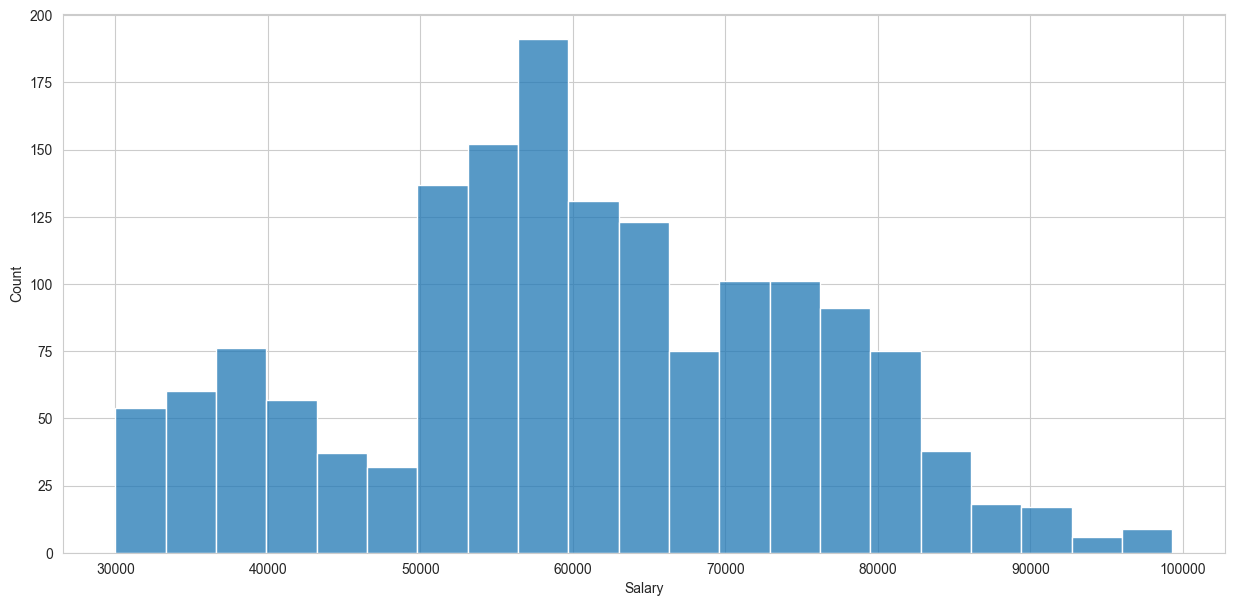

In [35]:
plt.figure(figsize=(15,7))
sns.histplot(df.Salary);

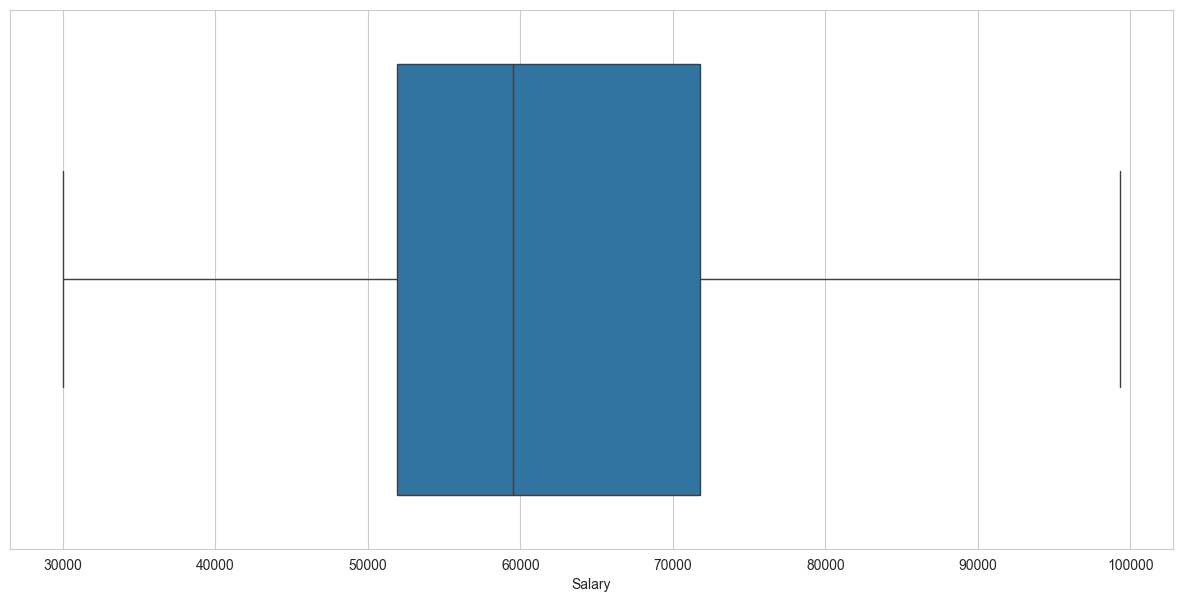

In [36]:
plt.figure(figsize=(15,7))
sns.boxplot(df.Salary, orient='h');


* As we can see that 50% of people are having salary ~59,0000
* There are no outliers in Salary variable

Observations on Price

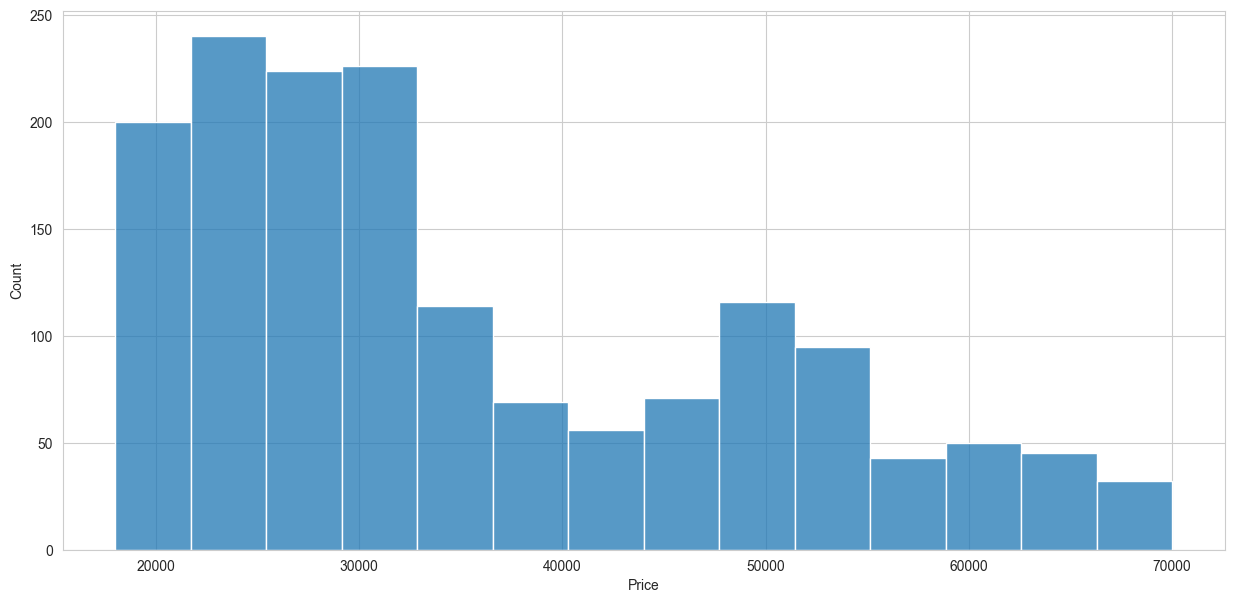

In [37]:
plt.figure(figsize=(15,7))
sns.histplot(df.Price);

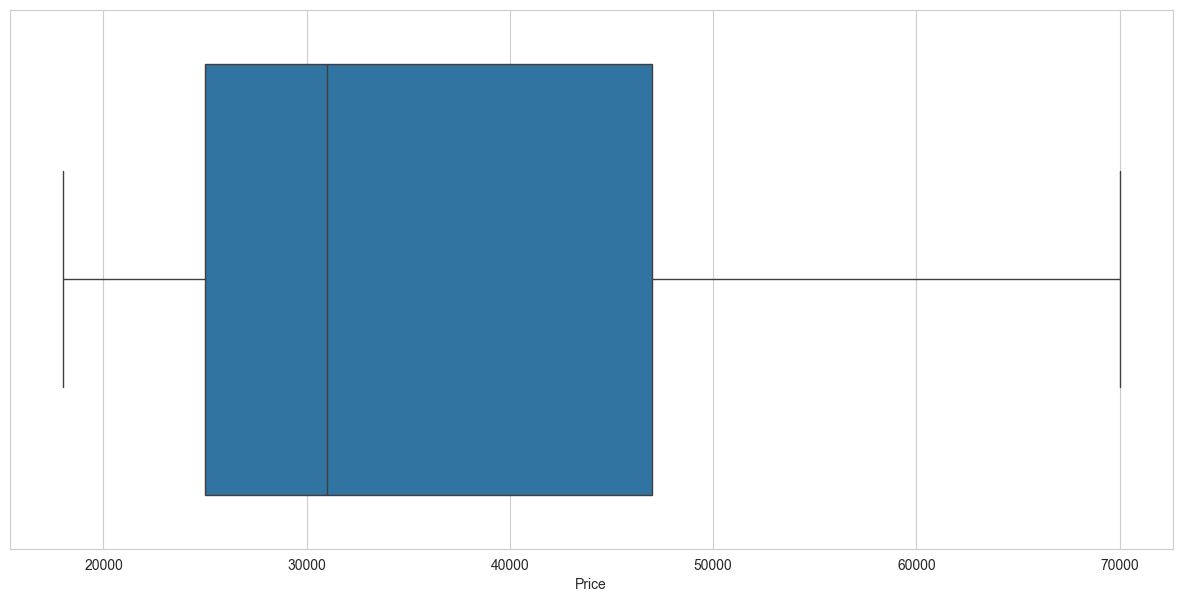

In [38]:
plt.figure(figsize=(15,7))
sns.boxplot(df.Price, orient='h');

* The distribution is skewed to the right
* There are no outliers in this variable
* The median is near about 32000 and 75th percentile is near 47000

Observations on Total Salary

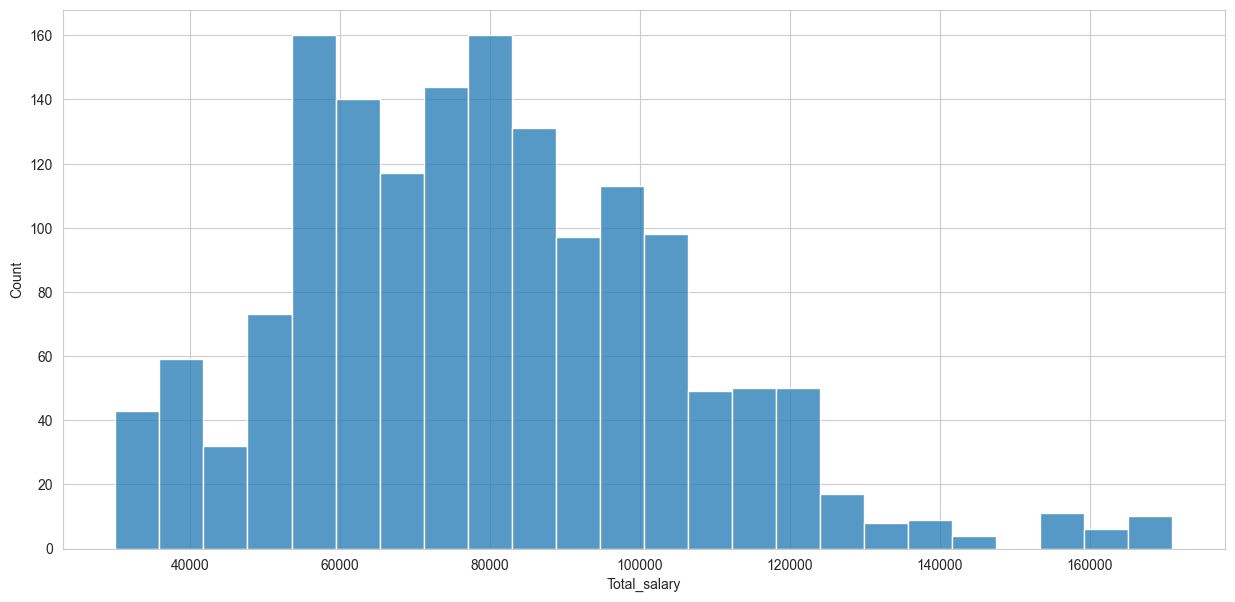

In [39]:
plt.figure(figsize=(15,7))
sns.histplot(df.Total_salary);

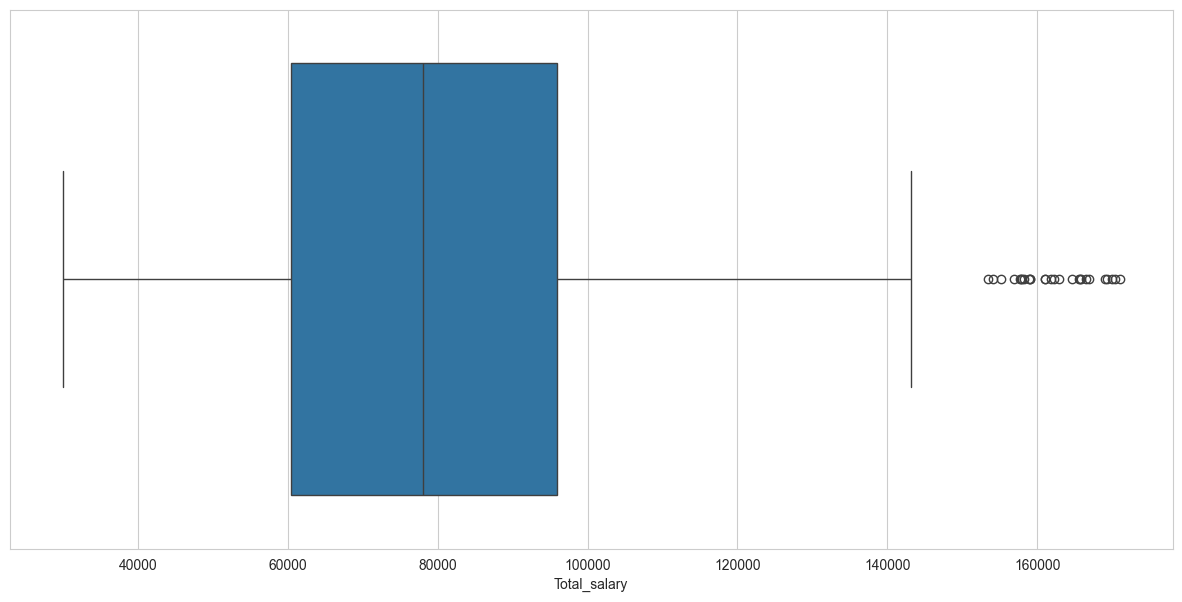

In [40]:
plt.figure(figsize=(15,7))
sns.boxplot(df.Total_salary, orient='h');

* Total Salary column is little bit right skewed
* There are few outliers on the right side representing high Total Salary and high buying capacity
* It will be interesting to see how the high total salary outliers are performing with other variables

Observations on Partner's Salary

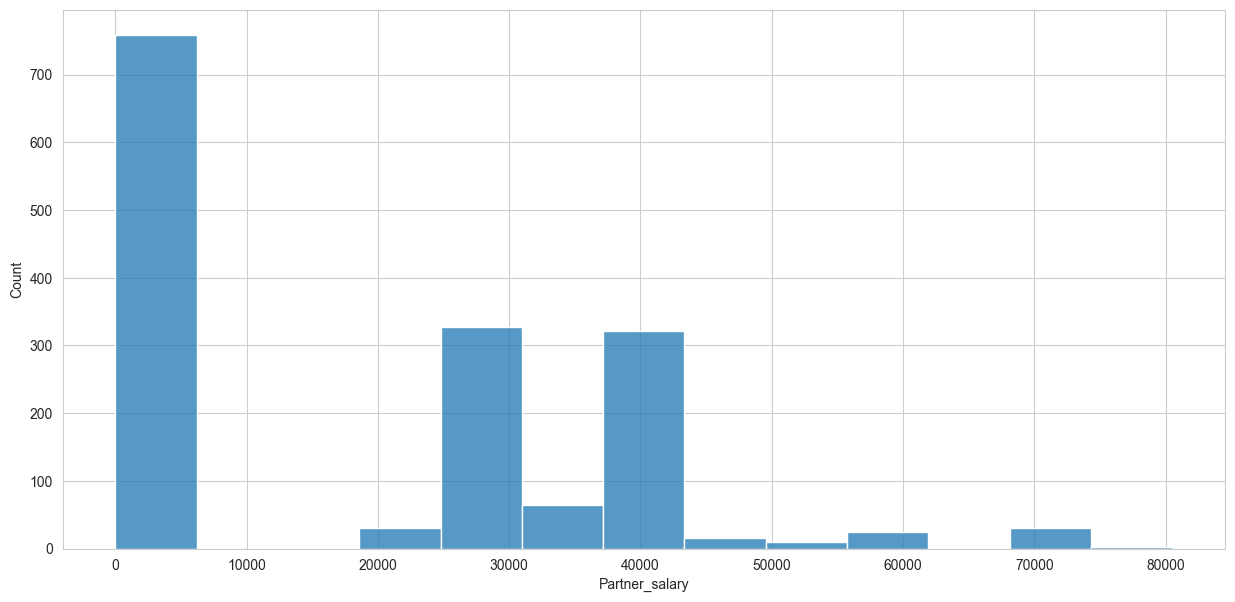

In [41]:
plt.figure(figsize=(15,7))
sns.histplot(df.Partner_salary);

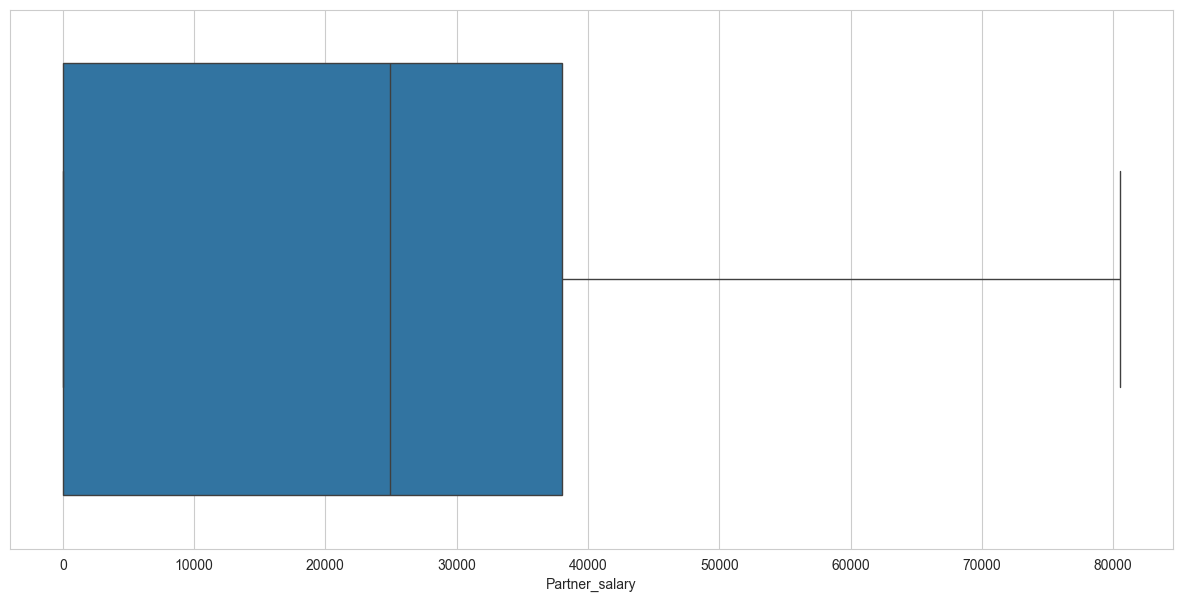

In [42]:
plt.figure(figsize=(15,7))
sns.boxplot(df.Partner_salary, orient='h');

* As observed before that, minimum and 25th percentile of partner's salary is shown 0
* There are no outliers, but imp to not highest partners salary is crossing 80000
* As per the histogram there are few inconsistencies with the partners salary and almost for 50% of partners salary, ie approx 750 people, is less than 7000.

Observations on No of Dependents


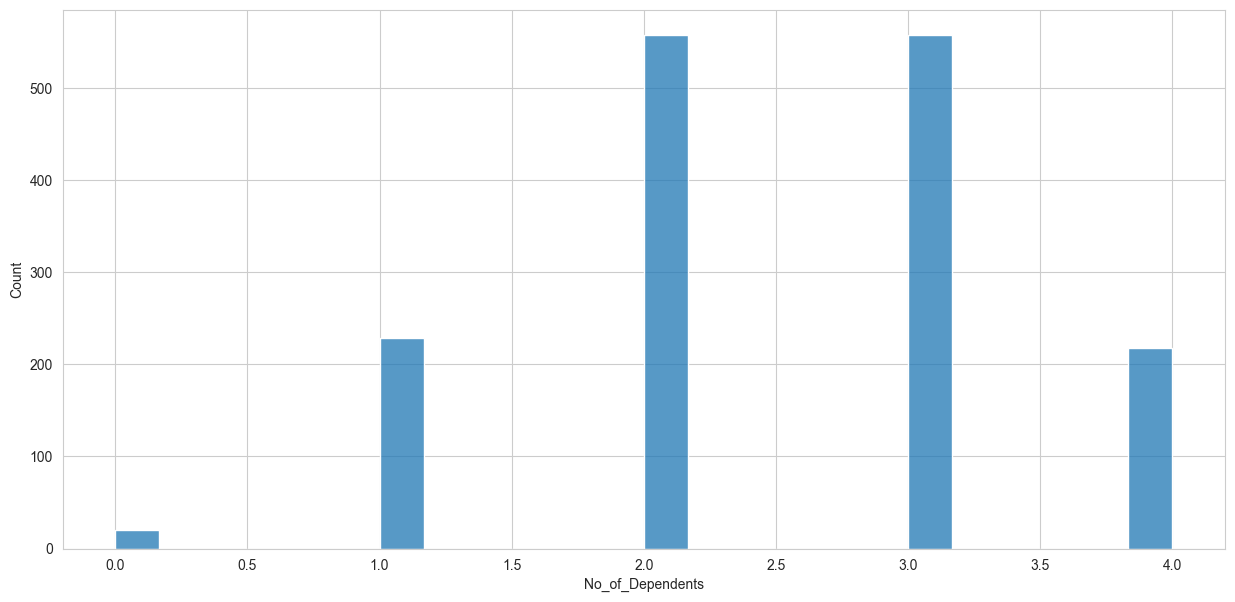

In [43]:
plt.figure(figsize=(15,7))
sns.histplot(df.No_of_Dependents);

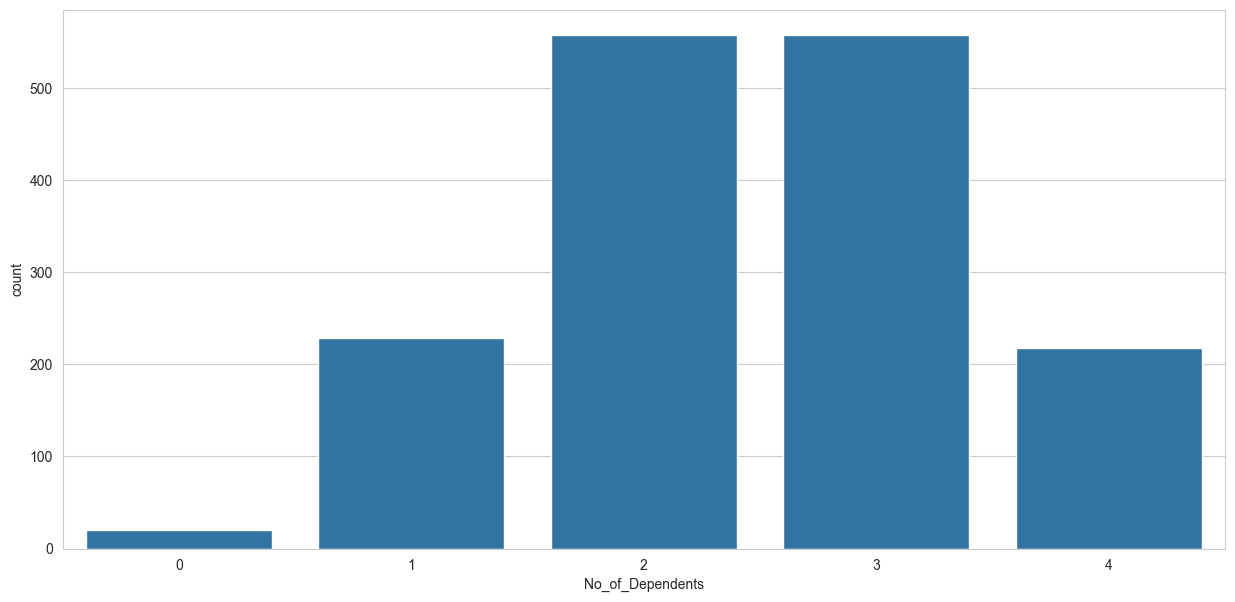

In [44]:
plt.figure(figsize=(15,7))
sns.countplot(data=df , x='No_of_Dependents');



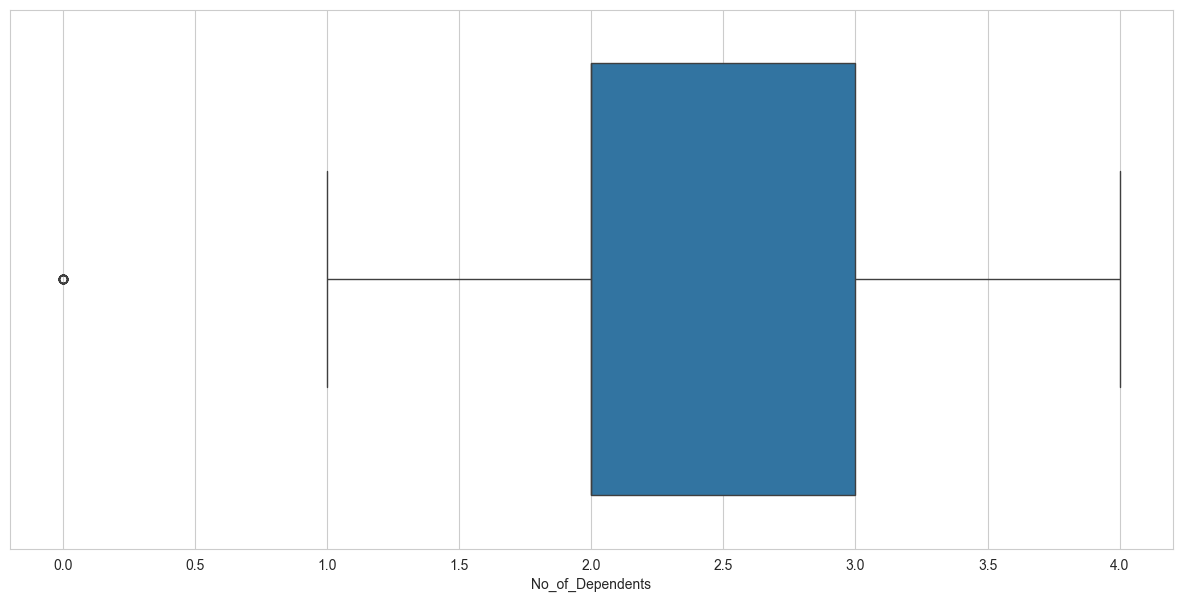

In [45]:
plt.figure(figsize=(15,7))
sns.boxplot(df.No_of_Dependents, orient='h');

* The only outlier is 0 which is obviously as there are single persons in the list
* Majority of people have 2-3 kids with 2 as median
* Need to further investigate the trend for type of car people with 2+ no of dependents prefer

Observation on Age

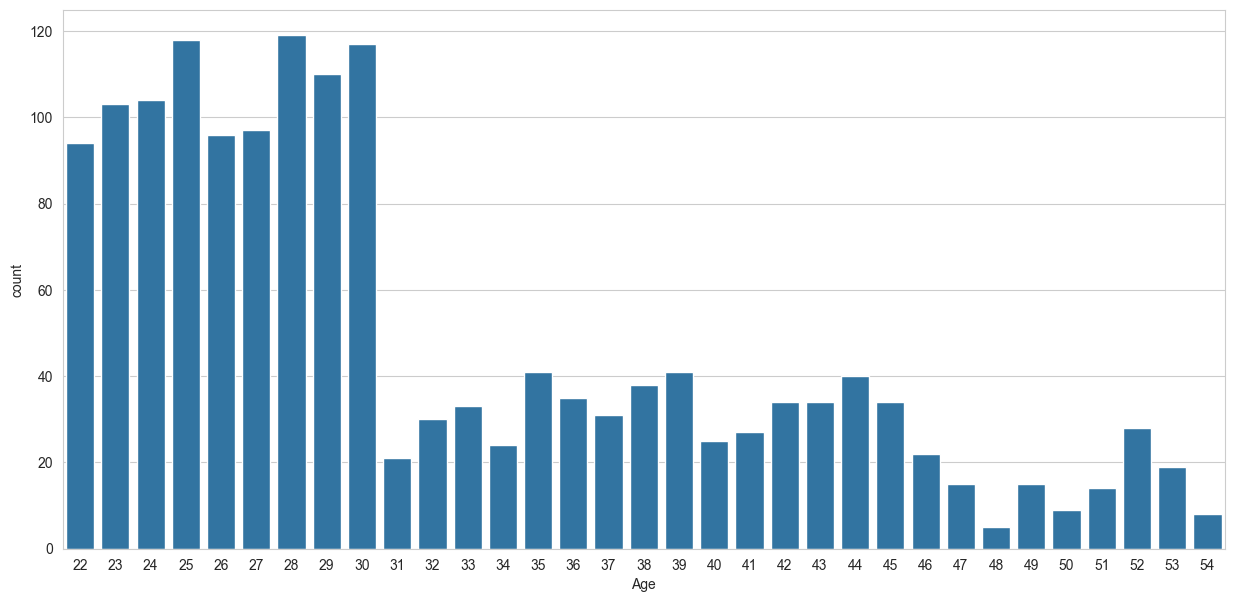

In [46]:
plt.figure(figsize=(15,7))
sns.countplot(data=df, x='Age');

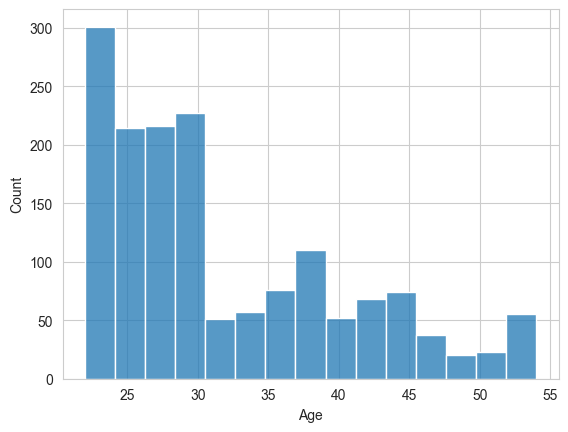

In [47]:
    sns.histplot(data=df, x='Age');

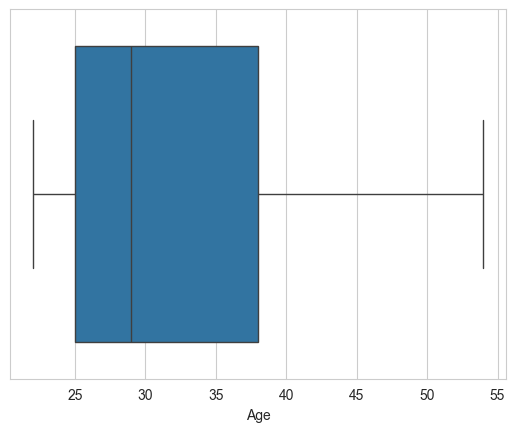

In [48]:
sns.boxplot(data=df, x='Age');

* Median Age of customers is 28, which means most of the customers are young, while 75% customers are of age 38

Lets Observe Categorical values


Observations on Gender

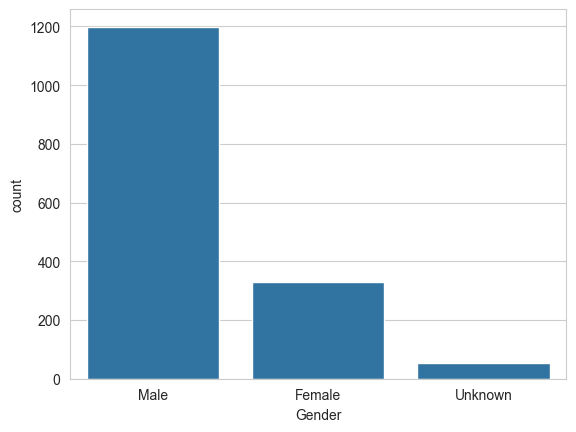

In [49]:
sns.countplot(data=df, x='Gender');

Most number of Cars are bought by men, approx 4x times more than women

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


Observations on Profession

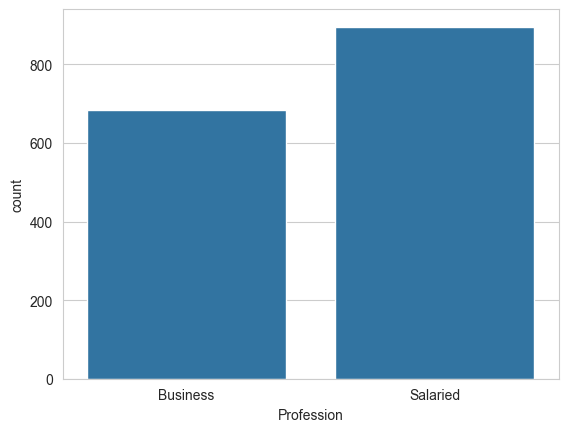

In [51]:
sns.countplot(data=df, x='Profession');

* Both Business person and salaried have good distribution
* There are more numbers of Salaried person then Business persons
* It would be interesting to see Cars Make bought by both professions later and how much price they have paid

Observations on Marital Status

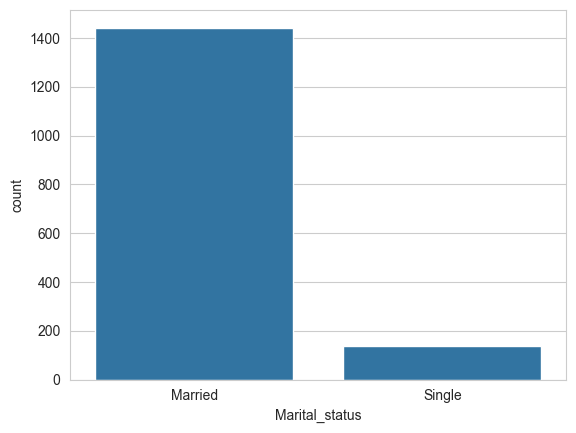

In [52]:
sns.countplot(data=df, x='Marital_status');

* Majority of cars are bought by married people which is not surprising
* It would be interesting to see single's choice of car make and price they paid

Observations on Education

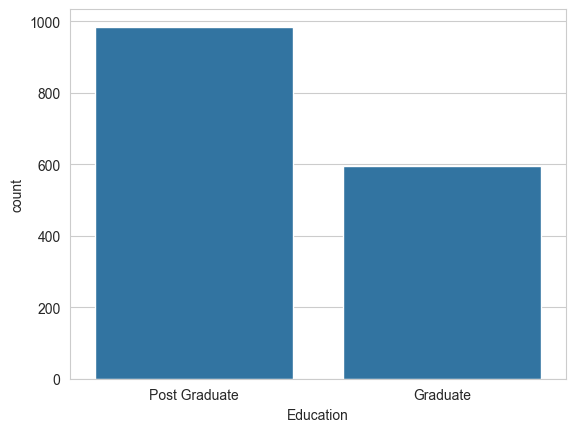

In [53]:
sns.countplot(data=df, x='Education');

* People with higher studies such as post graduation are more in terms of car owners

Observations on Perosnal loan

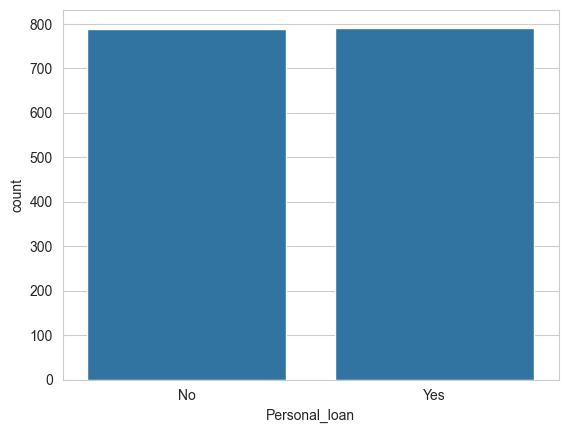

In [54]:
sns.countplot(data=df, x='Personal_loan');

* Personal loan taken and not taken both are similar with no clear indication of any trend in this variable

Observations on House loan


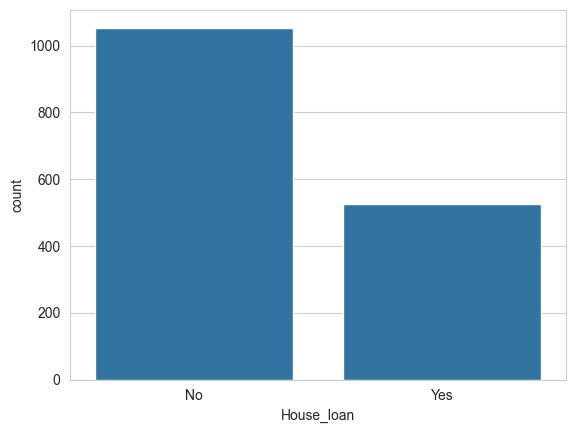

In [55]:
sns.countplot(data=df, x='House_loan');

* Customers with No house loan have taken more than 2x cars then the customers with house loans
* It is a good insight, as customers with lower financial burden of house loan tends to buy car more

Observation on Make of the car (Body Type)

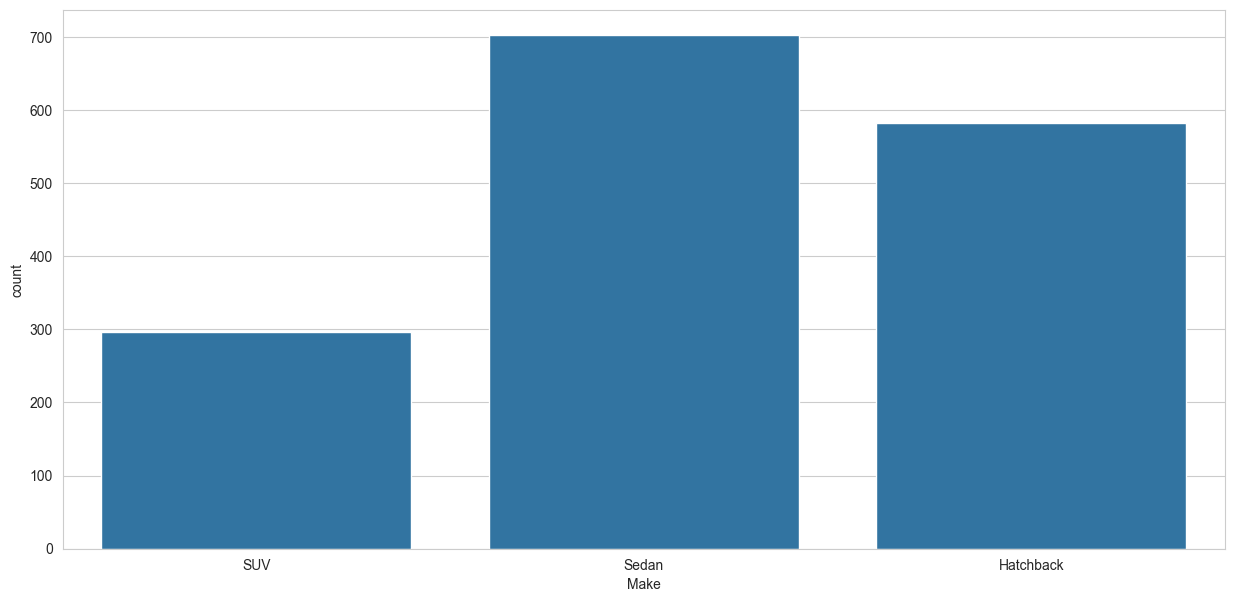

In [56]:
plt.figure(figsize=(15,7))
sns.countplot(data=df, x='Make');

In [57]:
df.groupby('Make')['Make'].value_counts()

Make
Hatchback    582
SUV          297
Sedan        702
Name: count, dtype: int64

* Customers prefer Sedan mostly and then Hatchback
* SUVs are bought the least by ~290 customers
* Importnat to note is the SUVs are generally expensive , so it could be major reason, we will investigate in detail in Bivariate analysis

## Bivariate Analysis

In The Bivariate analysis we will compare 3 types of variable to figure out the relationships
* Numeric and Numeric
* Numeric and Object
* Categorical and Categorical

In [58]:
#Selecting only numerical columns
num_var=df.dtypes[df.dtypes != 'object'].index

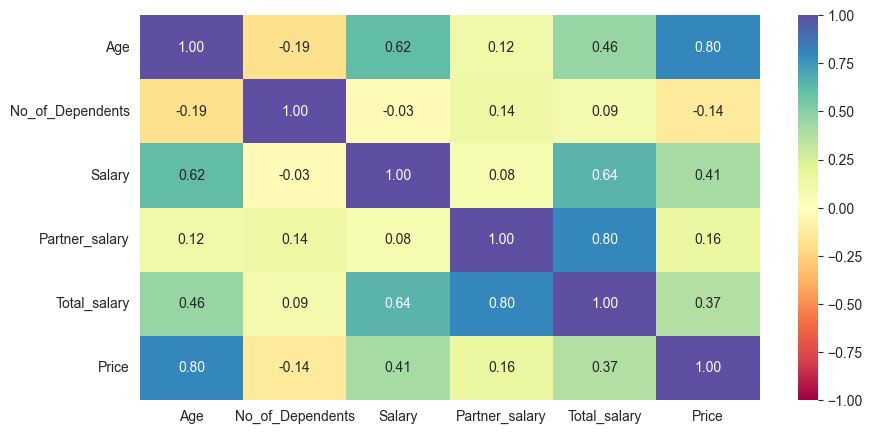

In [59]:
#plotting correlation heatmap
plt.figure(figsize=(10,5))
sns.heatmap(df[num_var].corr(),annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.show()

* Price shows strong correlation with Age as well as with Salary
* As expected Total Salary shows strong correlation with Partner's Salary as well as with individual's salary
* Partner's salary and individual's salary doesnt have any significant correlation
* There is a slight negative correlation with Age and no of dependents
* No significant relationship between No of dependents and Total salary or partner's salary and individual's salary, which is obvious and it doesnt imply and causation on another

#### Bivariate Scatter plot

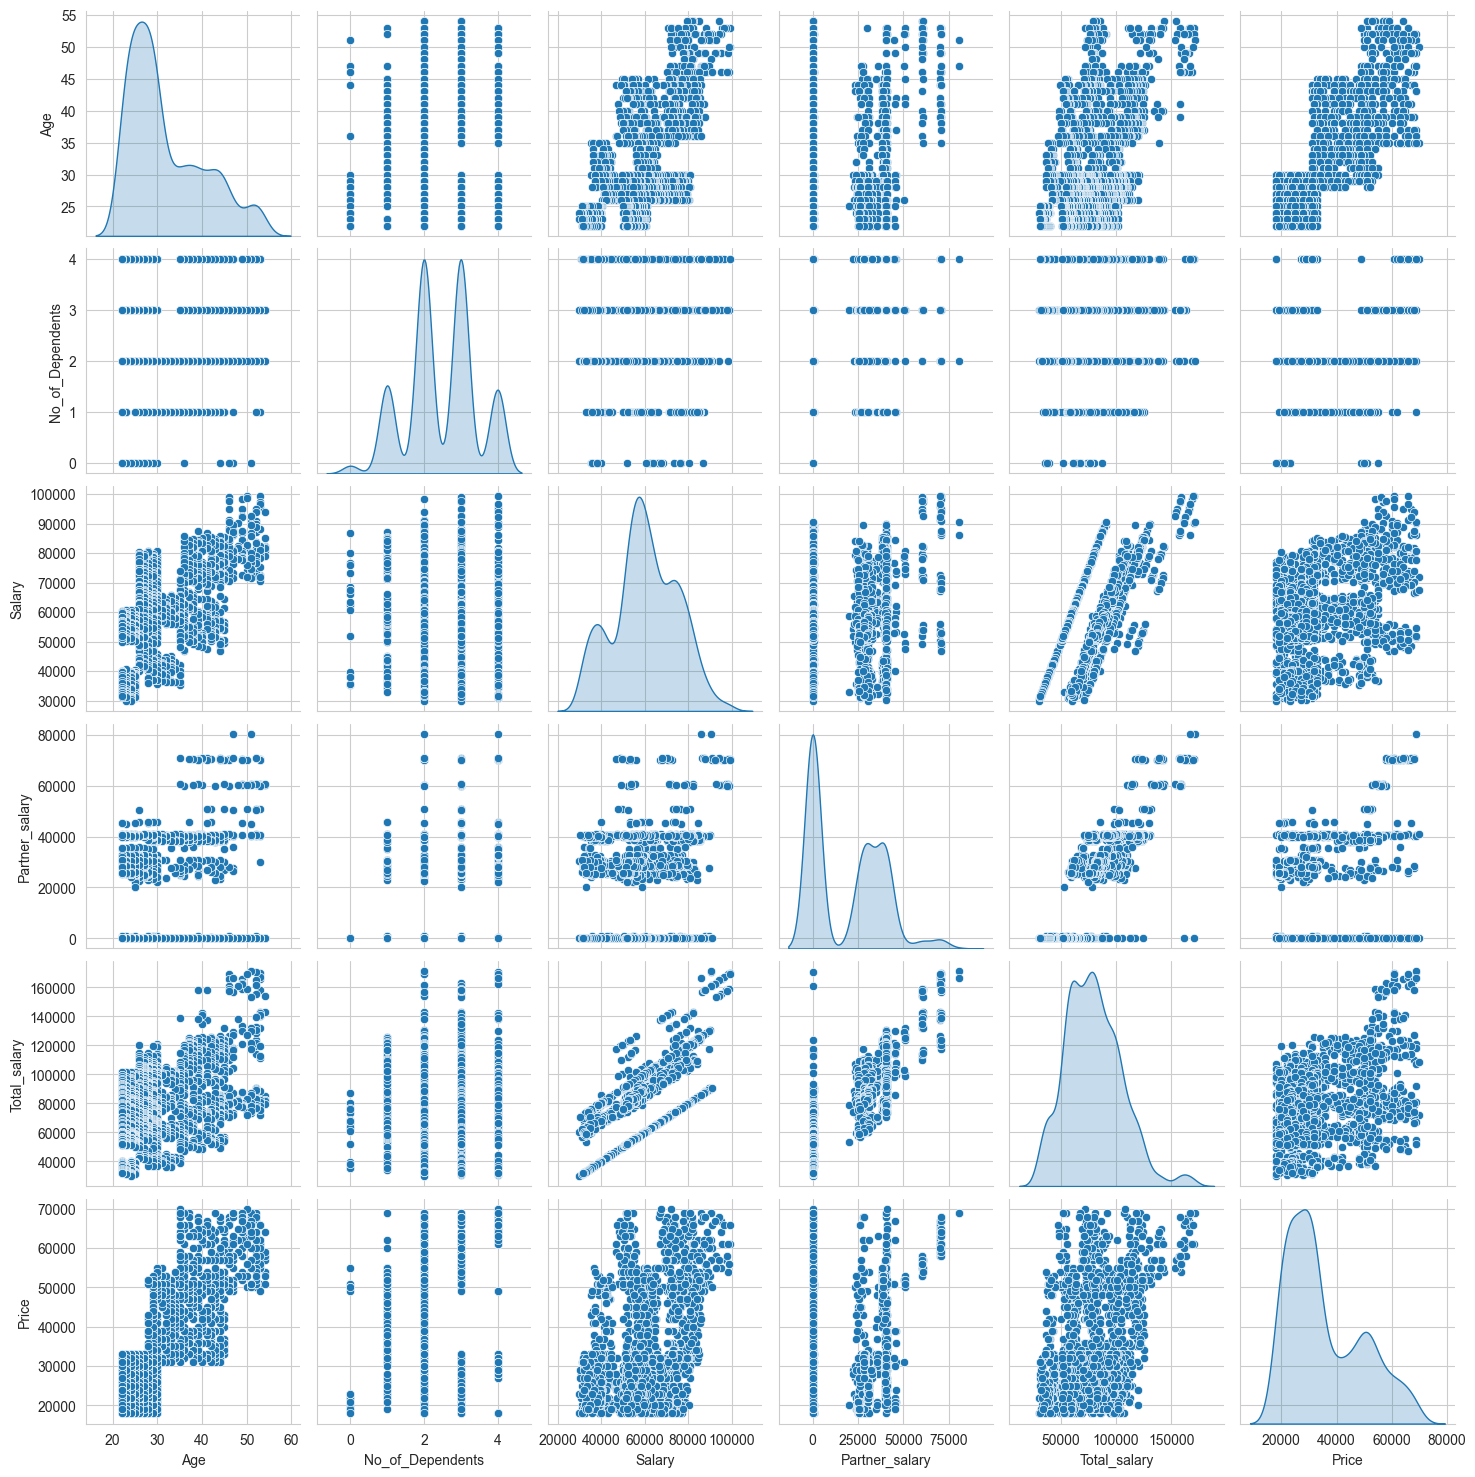

In [64]:
sns.pairplot(data=df[num_var], diag_kind='kde')
plt.show()

* It is interesting to note that No of dependents doesnt have any correlation with any other numerical factor, will need to investigate later with other categorical factor such as Make of the car
* Age shows a positive relationship with all Salary and total salary but with less impact with partner's salary
* As expected Salary has direct postive impact on Total salary, with not much significant impact on partners salary
* Partner's salary is contributing to Total salary , obviously
* We need to further investigate Total Salary and price relation and Price and Age relation to get  better insights

## Relationship between Price and Total Salary


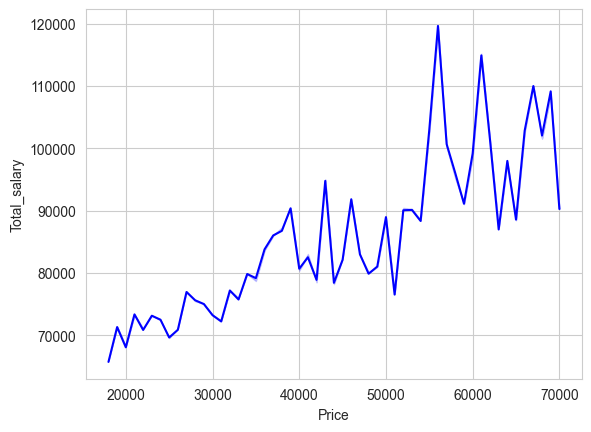

In [217]:
sns.lineplot(data=df, x='Price', y='Total_salary', errorbar=('ci',True), color='blue');

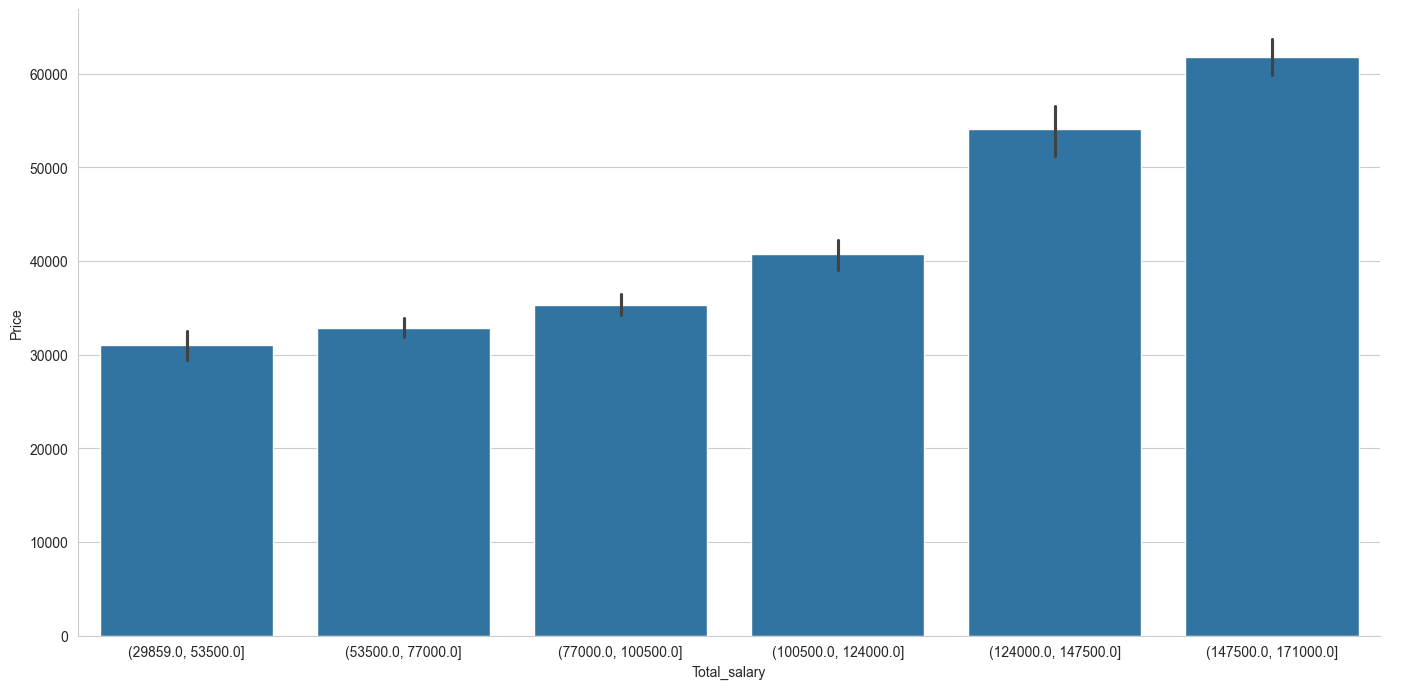

In [196]:
sns.catplot(data=df,x=pd.cut(df['Total_salary'], bins=6),y='Price',kind='bar', height=7,aspect=2);


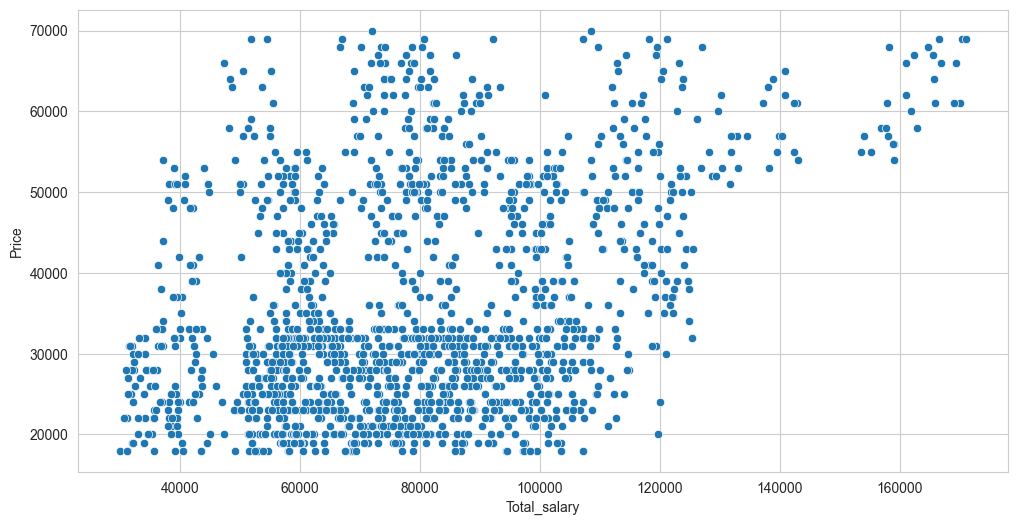

In [218]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Total_salary', y='Price');
plt.show()

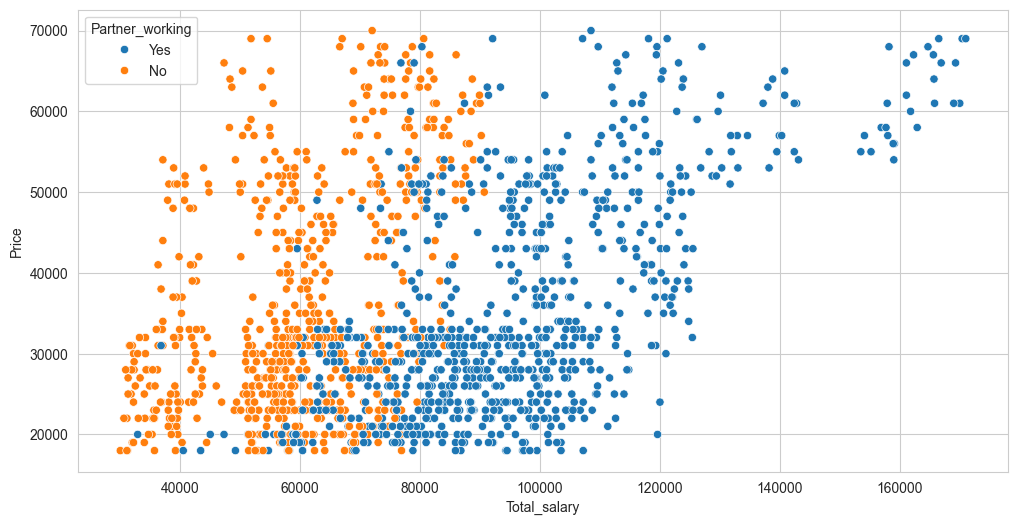

<Figure size 1200x600 with 0 Axes>

In [195]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Total_salary', y='Price' , hue='Partner_working');
plt.show()

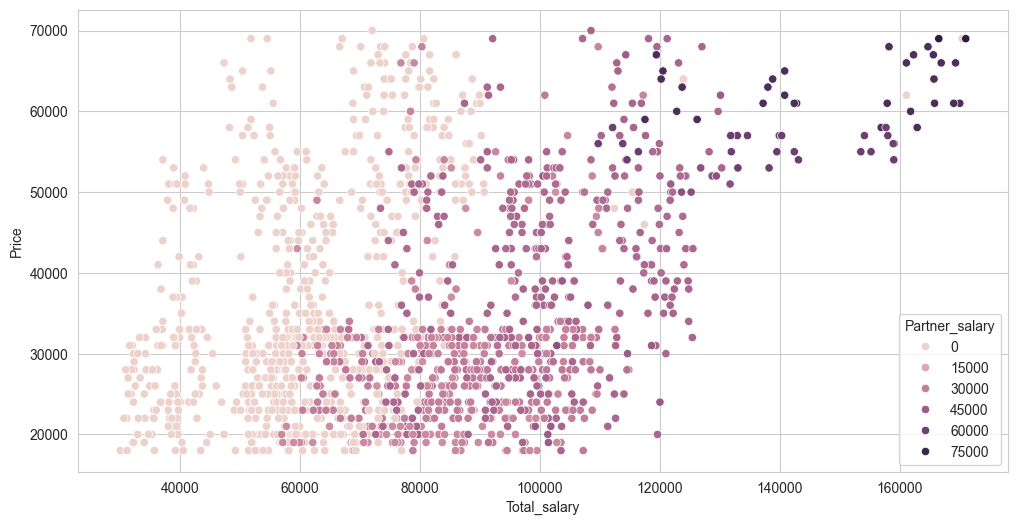

<Figure size 1200x600 with 0 Axes>

In [194]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Total_salary', y='Price' , hue='Partner_salary');
plt.show()

* Both the graphs shows that there is postive relationship as the Total salary increases , customer are paying higher price
* There is one more factor the rate of deviation from low salary to high salary is increasing,so we need to use box plot

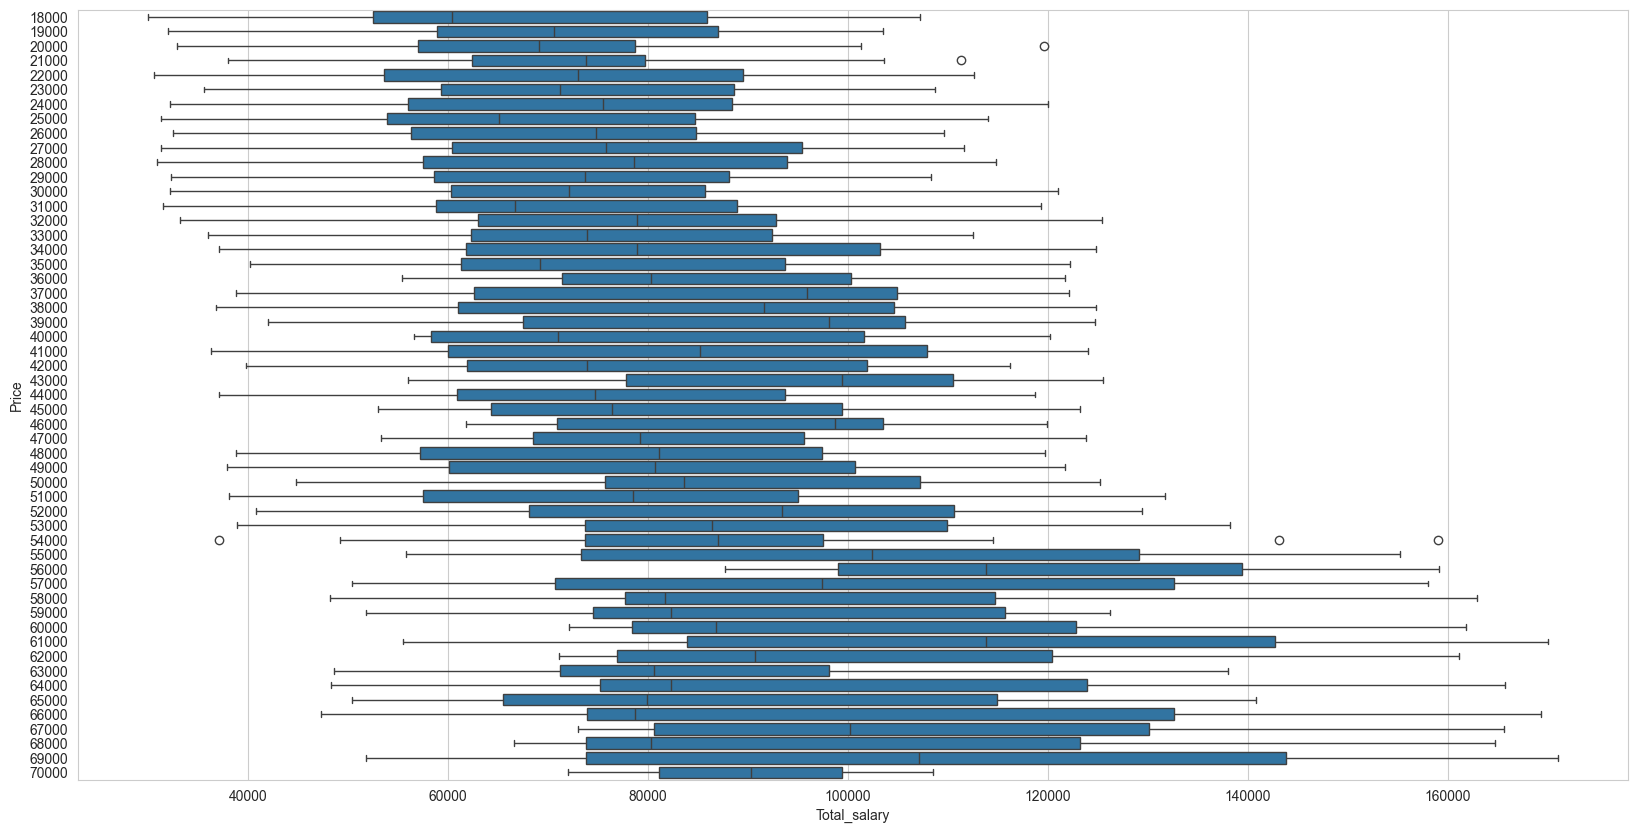

In [193]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df,y='Price',x='Total_salary',orient='h');


* We can see, some people with normal salary still buy big expensive cars
* Some very rich people also buy mid price cars, so salary mix is all over the place in middle price range.

## Relationship between Price and Age


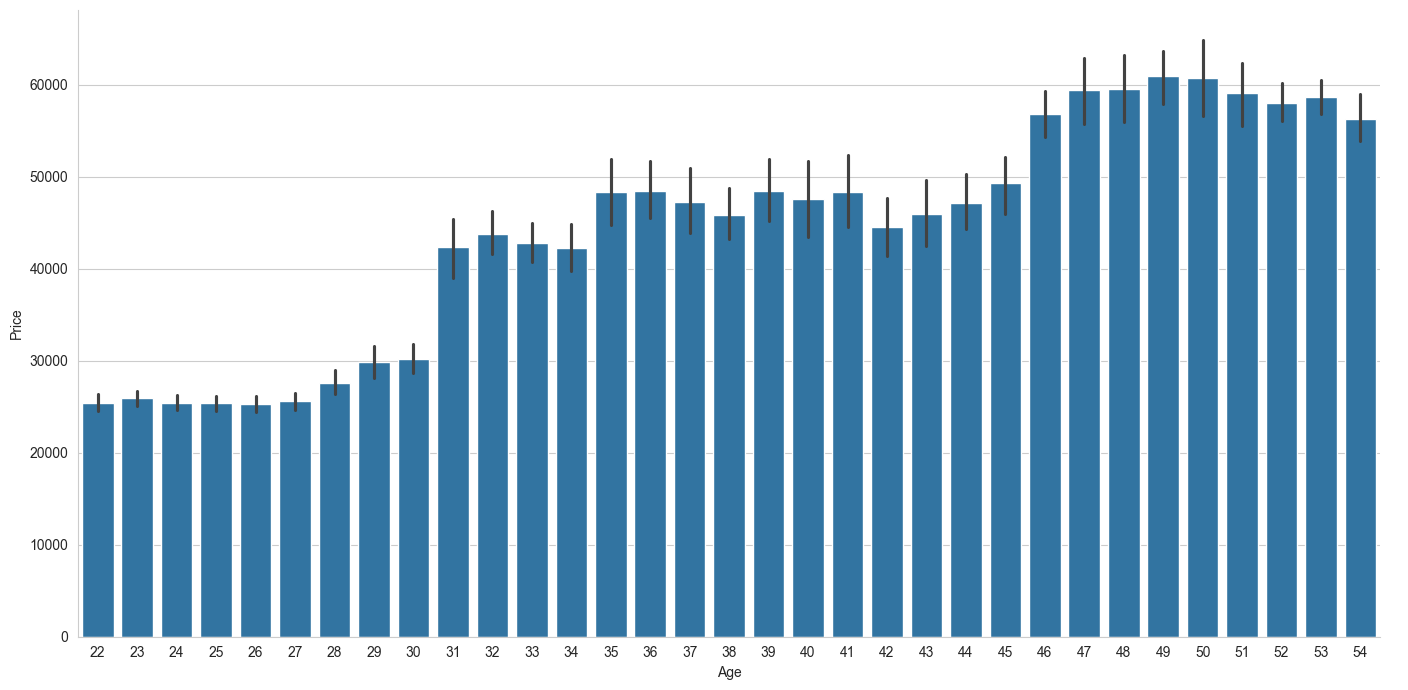

In [63]:
sns.catplot(data=df,x='Age',y='Price',kind='bar', height=7,aspect=2);


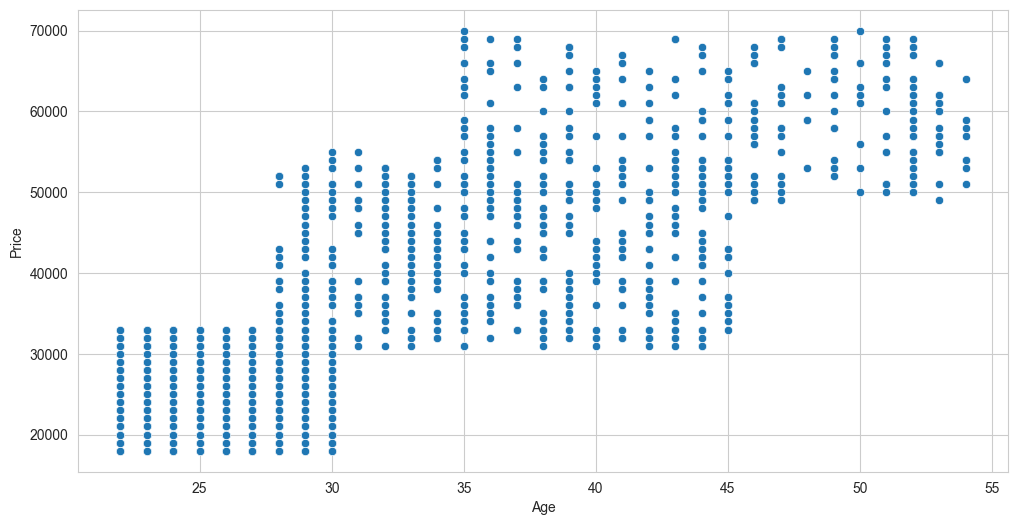

In [64]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Age', y='Price')
plt.show()

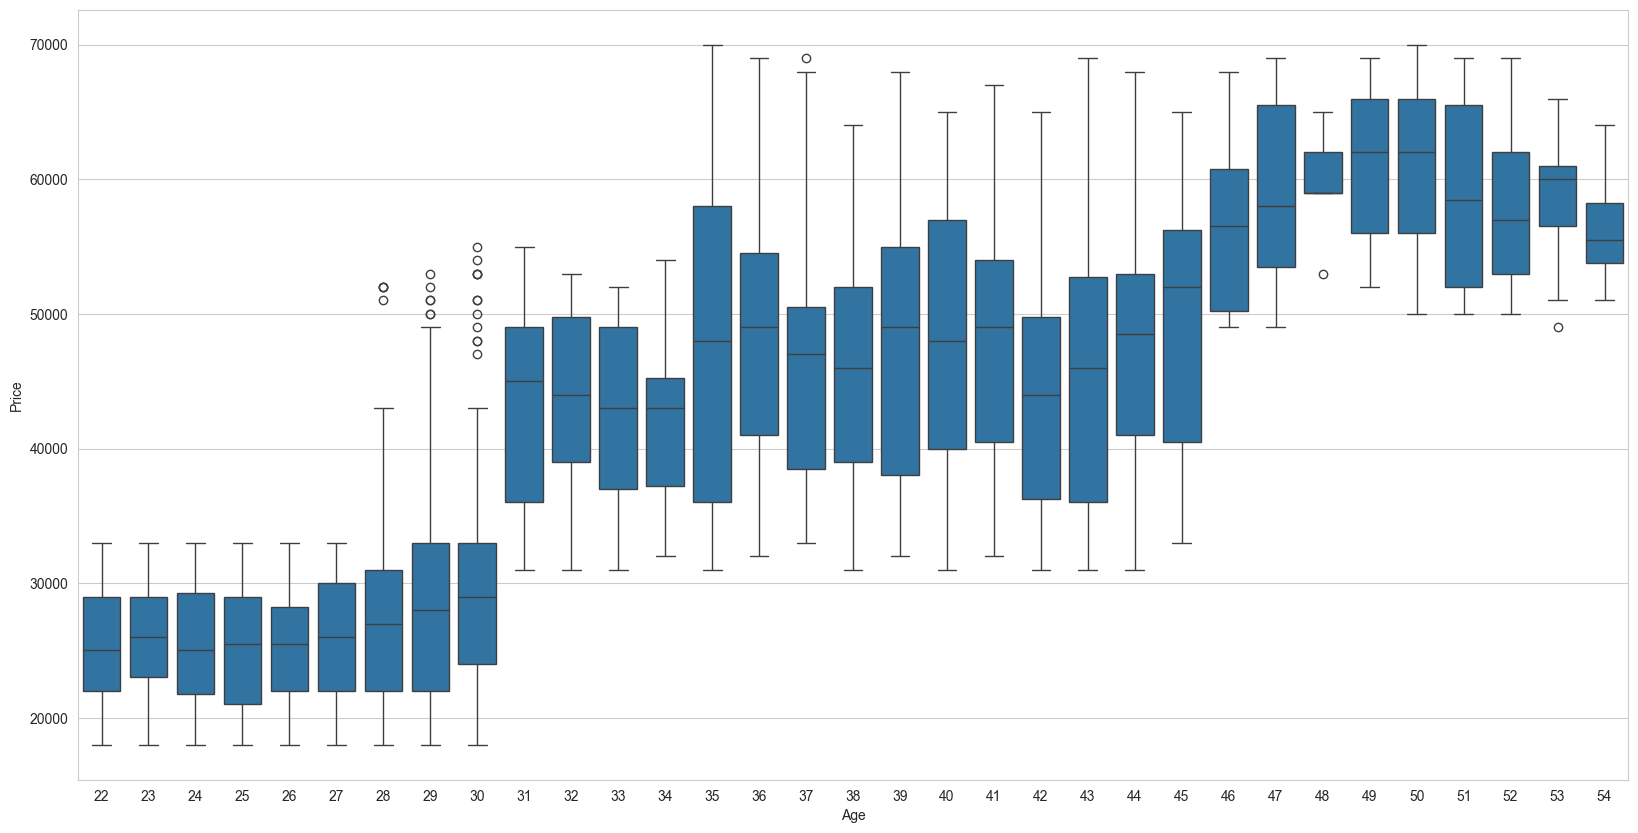

In [65]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df,y='Price',x='Age');


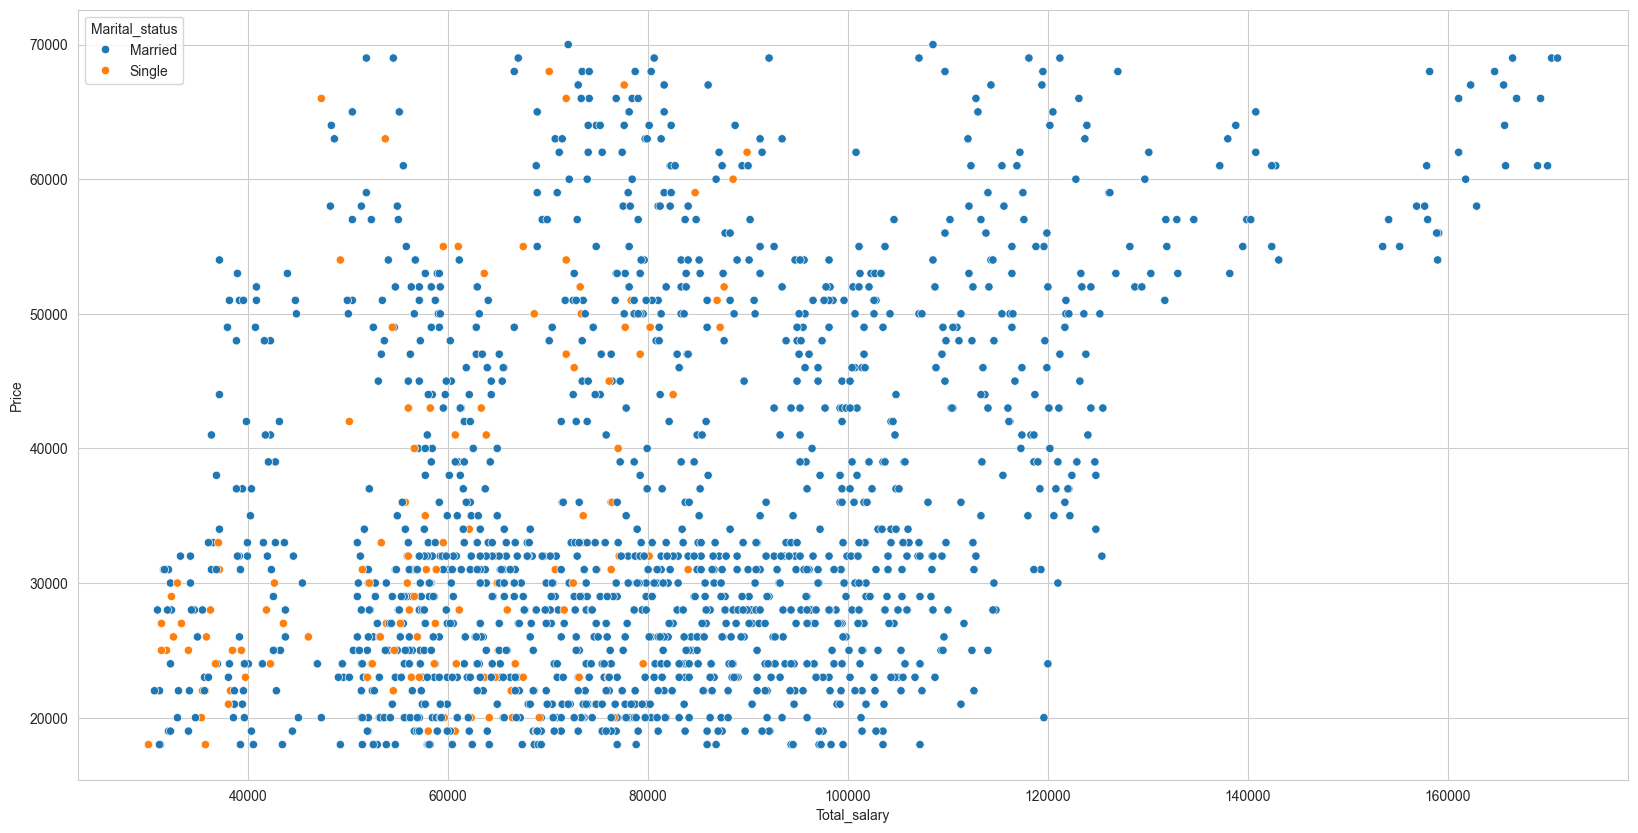

In [66]:
plt.figure(figsize=(20,10))
sns.scatterplot(data=df, x='Total_salary', y='Price', hue='Marital_status');
plt.show()

* As Expected Customer paying for expensive cars are married people mostly


Relationship Between Price and Gender

<Axes: xlabel='Price', ylabel='Gender'>

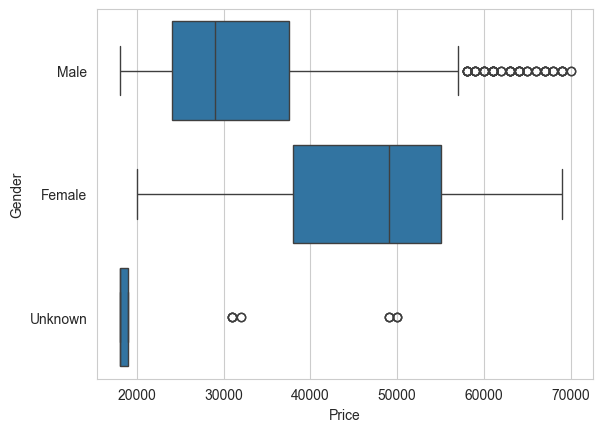

In [306]:
sns.boxplot(data=df, x='Price', y='Gender')


In [310]:
df.groupby(['Gender','Make'])['Price'].sum()


Gender   Make     
Female   Hatchback      412000
         SUV           9252000
         Sedan         6031000
Male     Hatchback    14959000
         SUV           7031000
         Sedan        17358000
Unknown  Hatchback       37000
         SUV            297000
         Sedan          903000
Name: Price, dtype: int64

In [312]:
df.groupby('Gender')['Price'].agg(['sum','mean'])

,sum,mean
Gender,,
Female,15695000,47705.167173
Male,39348000,32817.347790
Unknown,1237000,23339.622642


Relationship between No of Dependents and Price

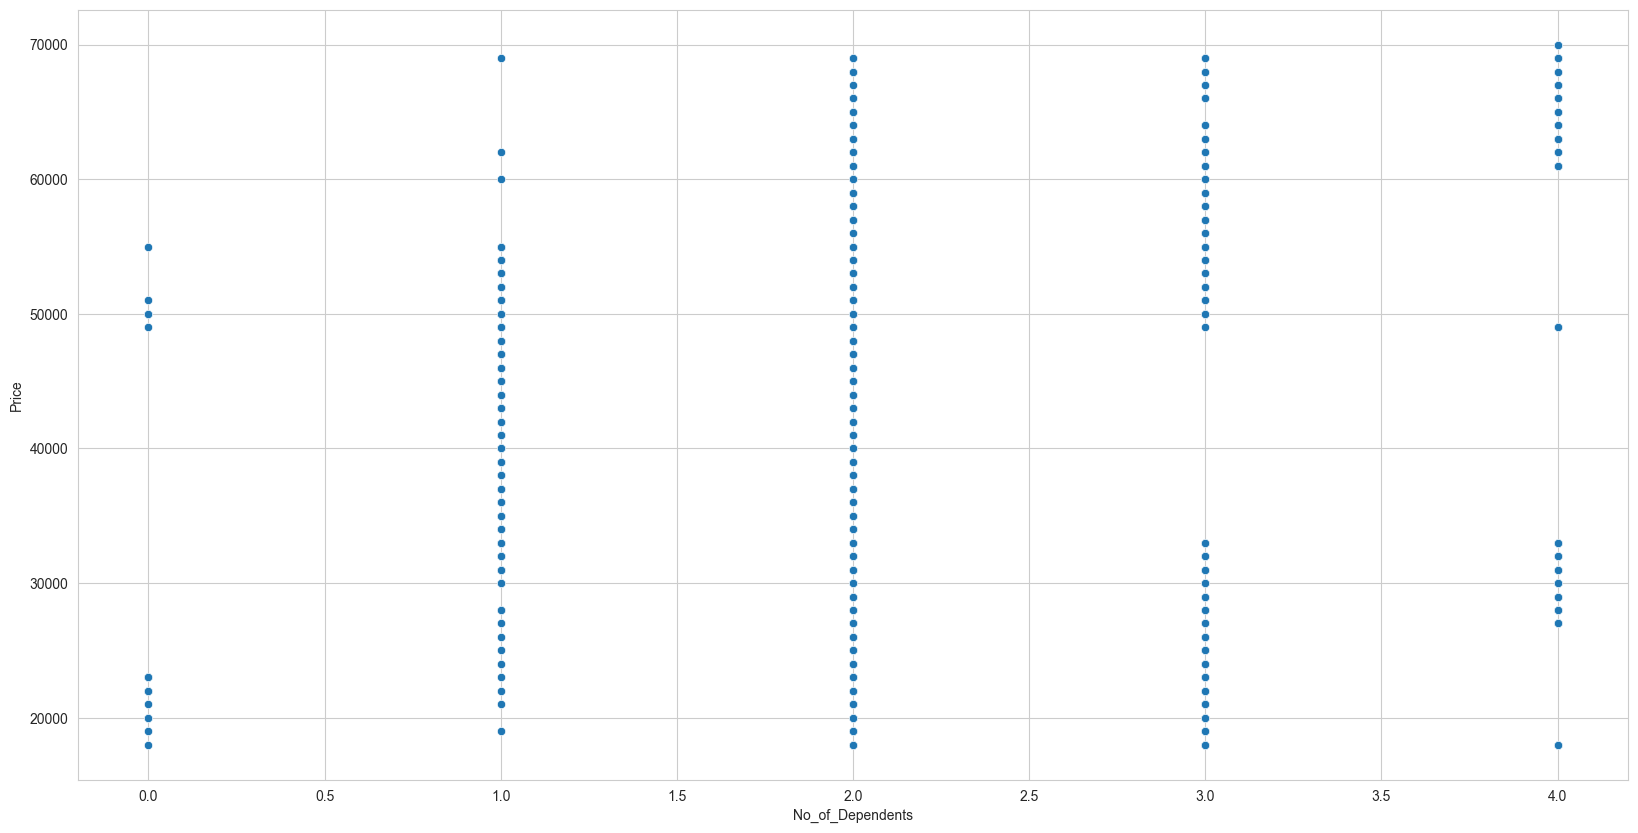

In [67]:
plt.figure(figsize=(20,10))
sns.scatterplot(data=df, x='No_of_Dependents', y='Price')
plt.show()

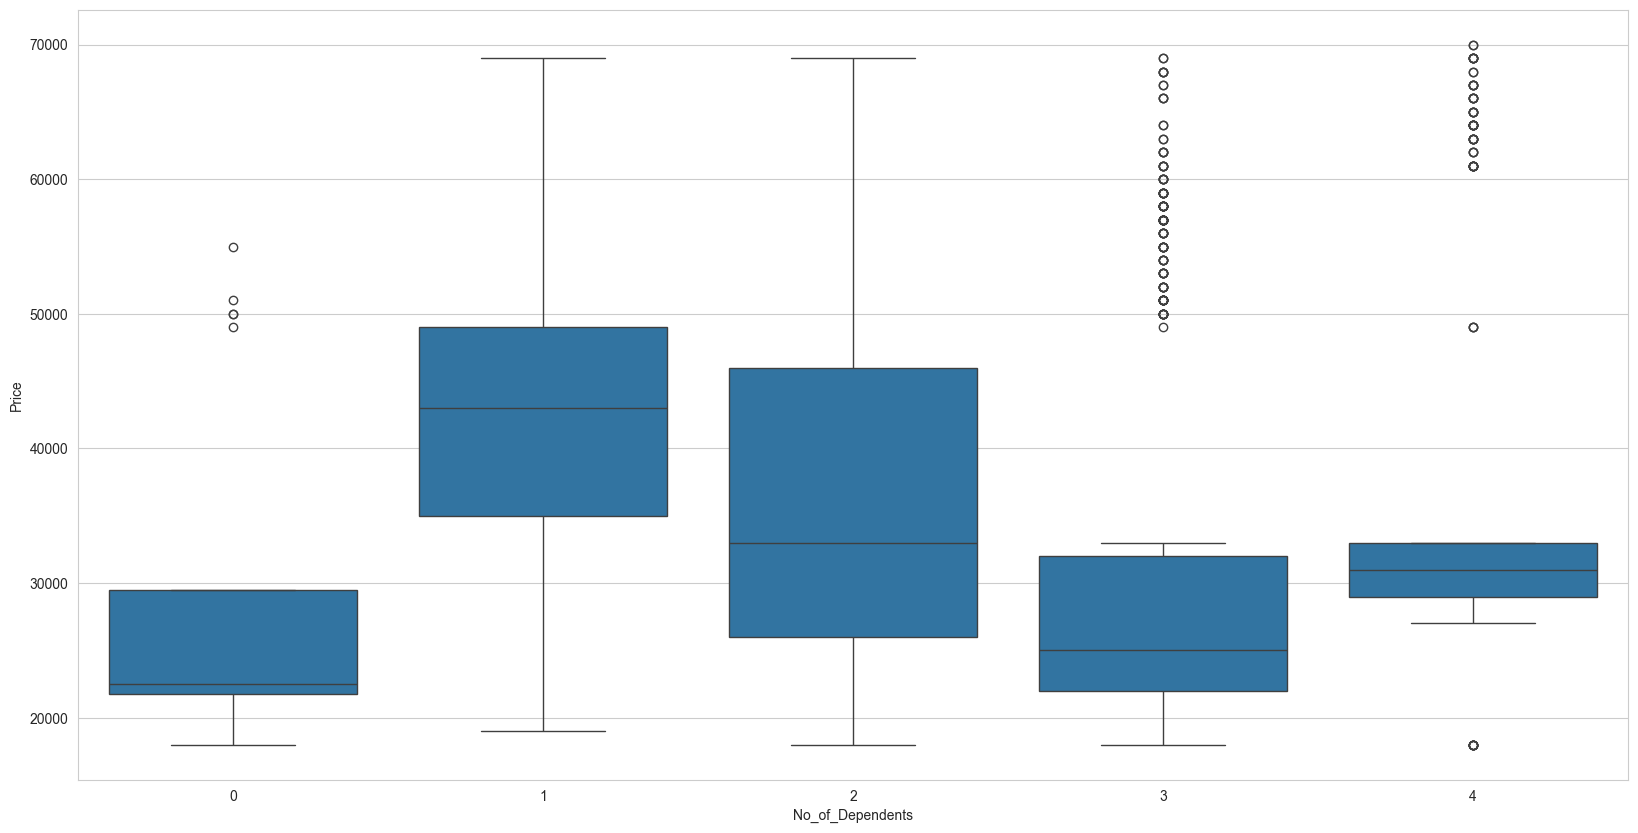

In [68]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df, x='No_of_Dependents', y='Price')
plt.show()

* No of customers with 1 No of dependent seems to be paying high amount of cars and followed by 2 no of dependents on them
* It clearly means that there are customers who are single and in early career age and doesnt need an expensive car right away
* People with only 1 dependent could be newly married with wife and have more desposible income to spend on cars, we need to investigate later about their loans status
* People with 2 dependent, could be having one child and comparitvily have more desposible income then people with 3 and 4 people dependent on them
* There is a chnace some people with no of dependet 1 and 2 could be single and , and parents are dependent on them, will investigate it

<Figure size 2000x1000 with 0 Axes>

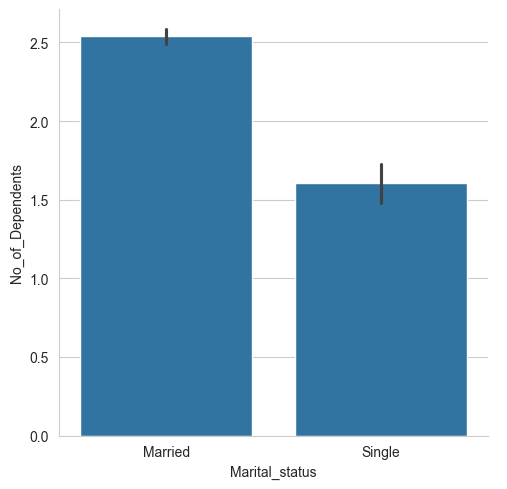

In [69]:
plt.figure(figsize=(20,10))
sns.catplot(data=df, x='Marital_status', y='No_of_Dependents', kind='bar')
plt.show()


* As the no of dependts are integer, it is showing avg value and not giving accurate data
* We need to convert no of dependents into object to have accurate insights

In [70]:
df['Dependents_obj'] = df['No_of_Dependents'].astype('object')

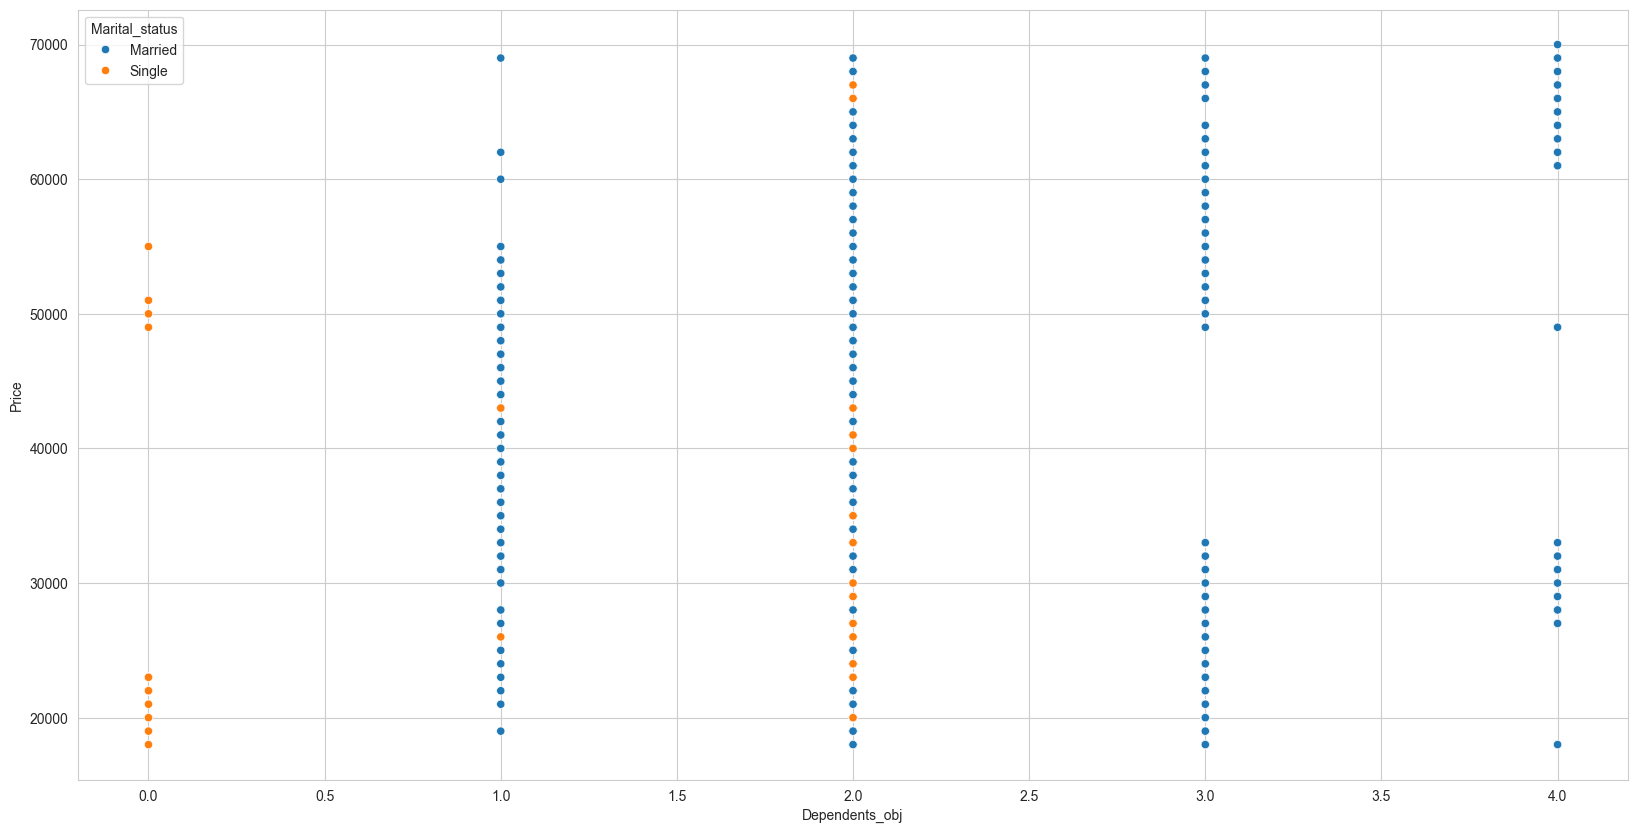

In [71]:
plt.figure(figsize=(20,10))
sns.scatterplot(data=df, hue='Marital_status', x='Dependents_obj', y='Price')
plt.show()

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
 14  Dependents_obj    1581 non-null   object 
dtypes: float64(1), int64(5), object(9)
memory usage: 185.4+ KB


## Now Catagorical relationships we will observe


Relationship between make and gender

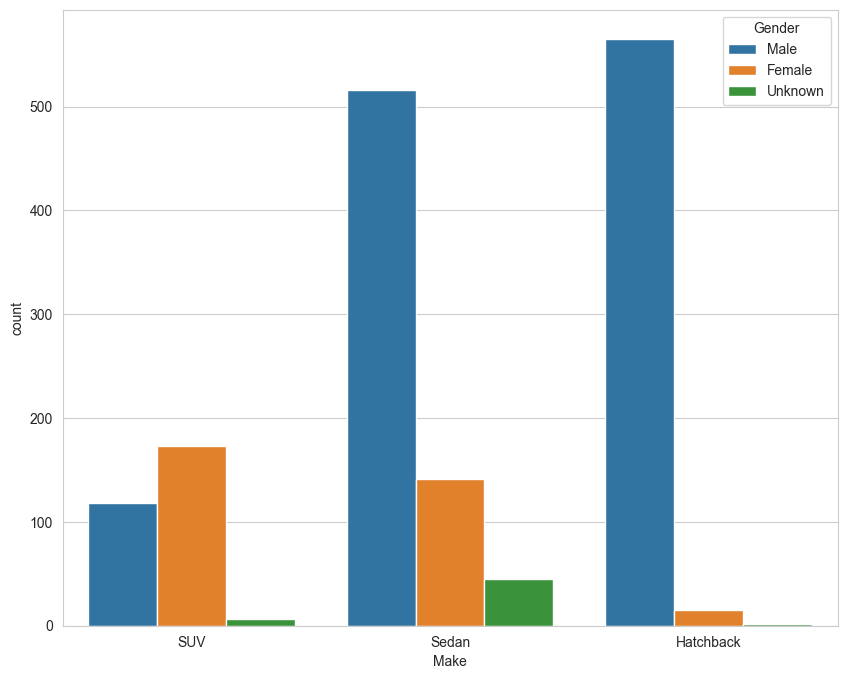

In [73]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x='Make', hue='Gender')
plt.show()

In [220]:
df.groupby('Make')['Gender'].value_counts()

Make       Gender 
Hatchback  Male       565
           Female      15
           Unknown      2
SUV        Female     173
           Male       118
           Unknown      6
Sedan      Male       516
           Female     141
           Unknown     45
Name: count, dtype: int64

In [222]:
df.groupby('Make')['Gender'].value_counts(normalize=True).mul(100)

Make       Gender 
Hatchback  Male       97.079038
           Female      2.577320
           Unknown     0.343643
SUV        Female     58.249158
           Male       39.730640
           Unknown     2.020202
Sedan      Male       73.504274
           Female     20.085470
           Unknown     6.410256
Name: proportion, dtype: float64

In [219]:
make_gender = (df.groupby('Make')['Gender'].value_counts(normalize=True).mul(100).rename('Percent').reset_index())

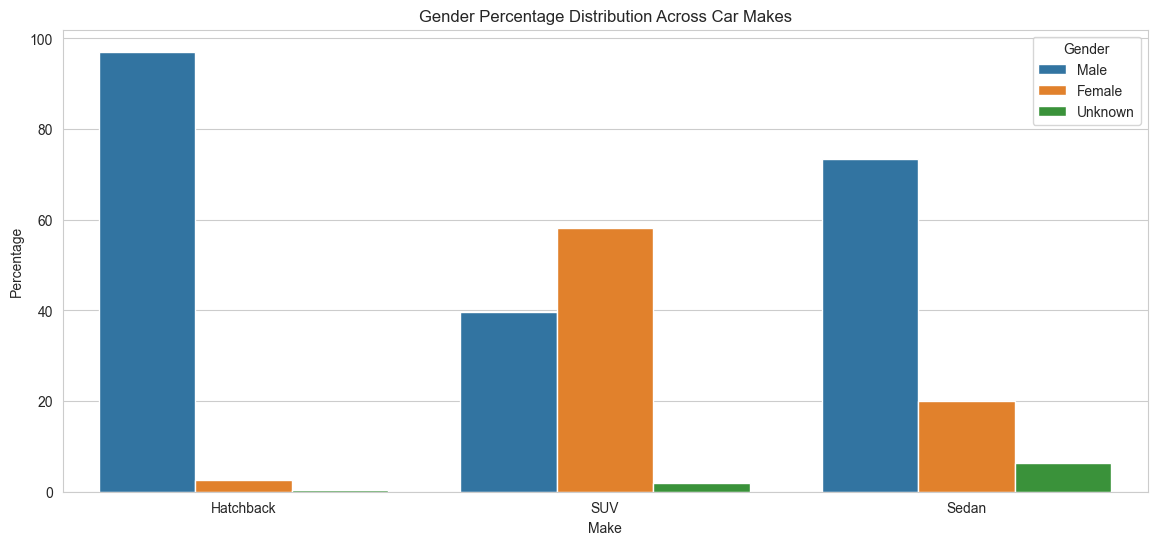

In [76]:
plt.figure(figsize=(14,6))
sns.barplot(data=make_gender, x='Make', y='Percent', hue='Gender')
plt.ylabel('Percentage')
plt.title('Gender Percentage Distribution Across Car Makes')
plt.show()

* As we can see 97% hatchback are bought by males
* Its interesting to note, Females prefer SUV which is more than 20% over males

Relationship between Make and profession

In [223]:
df.groupby('Make')['Profession'].value_counts(normalize=True).mul(100)

Make       Profession
Hatchback  Salaried      50.171821
           Business      49.828179
SUV        Salaried      70.033670
           Business      29.966330
Sedan      Salaried      56.410256
           Business      43.589744
Name: proportion, dtype: float64

In [289]:
df.groupby('Profession')['Make'].value_counts(normalize=True) * 100


Profession  Make     
Business    Sedan        44.671533
            Hatchback    42.335766
            SUV          12.992701
Salaried    Sedan        44.196429
            Hatchback    32.589286
            SUV          23.214286
Name: proportion, dtype: float64

In [78]:
make_profession = (df.groupby('Make')['Profession'].value_counts(normalize=True).mul(100).rename('Per_Make_Prof').reset_index())

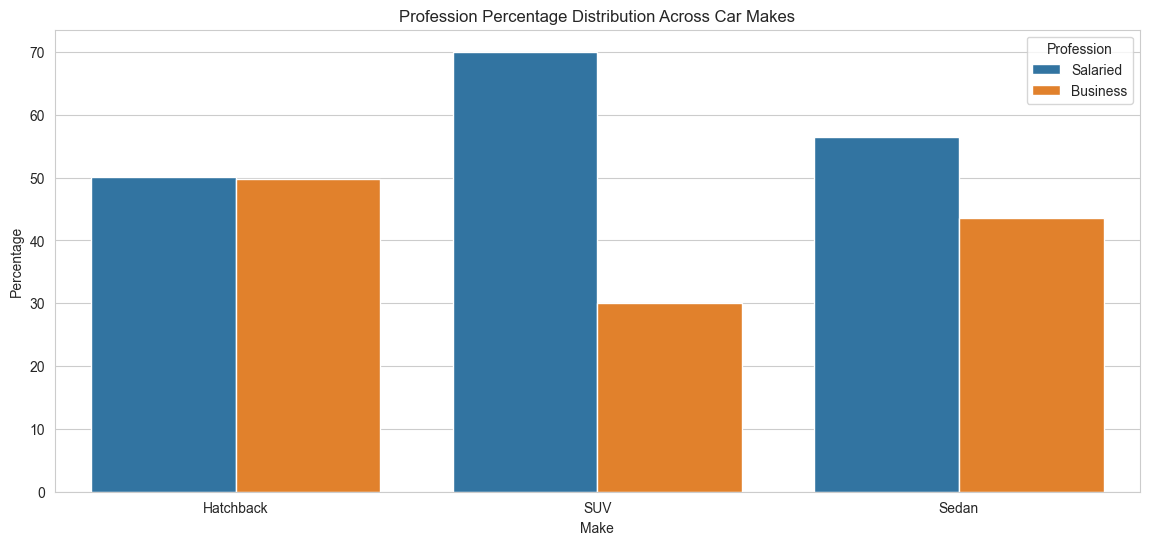

In [79]:
plt.figure(figsize=(14,6))
sns.barplot(data=make_profession, x='Make', y='Per_Make_Prof', hue='Profession')
plt.ylabel('Percentage')
plt.title('Profession Percentage Distribution Across Car Makes')
plt.show()

* Hatchback Car are bought almost equally among both Salaried and Business professions
* While we can see SUV are bought much more by Salaried person than Business professionals
* Sedan also is bought more by salaried person, it would be interesting to see there relationship with there income

Info on Profession and Total Salary

In [80]:
df.groupby('Profession')['Total_salary'].agg(Count='count', Mean='mean', Min='min', Max='max', Median='median')

,Count,Mean,Min,Max,Median
Profession,,,,,
Business,685,78658.102190,30600,170400,77700.0
Salaried,896,80365.959821,30000,171000,78000.0


* Both Business person and Salaried person have almost similar avg salary, min and max salary and even median is almost similar, no biasness towards one variable

Relationship Between Personal Loan and customers with their car make

In [81]:
df.groupby('Make')['Personal_loan'].value_counts()

Make       Personal_loan
Hatchback  No               291
           Yes              291
SUV        No               181
           Yes              116
Sedan      Yes              385
           No               317
Name: count, dtype: int64

* There seems to be no indication of any relationship tying  whether having personal loan, affecting the choice of car

In [224]:
df.groupby('Make')['Personal_loan'].value_counts(normalize=True)


Make       Personal_loan
Hatchback  No               0.500000
           Yes              0.500000
SUV        No               0.609428
           Yes              0.390572
Sedan      Yes              0.548433
           No               0.451567
Name: proportion, dtype: float64

Relationship Between House Loan and customers with their car make


In [82]:
df.groupby('Make')['House_loan'].value_counts()

Make       House_loan
Hatchback  No            347
           Yes           235
SUV        No            275
           Yes            22
Sedan      No            432
           Yes           270
Name: count, dtype: int64

In [83]:
df.groupby('Make')['House_loan'].value_counts(normalize=True)

Make       House_loan
Hatchback  No            0.596220
           Yes           0.403780
SUV        No            0.925926
           Yes           0.074074
Sedan      No            0.615385
           Yes           0.384615
Name: proportion, dtype: float64

* Having a house loan is clearly affecting the decision to buy car in all 3 car types
* It is imp to note , Car type SUV, which is generally considered expensive, are bought mostly by customers(92%) not having house loan


Relationship between Make and Partner Working

In [84]:
df.groupby('Make')['Partner_working'].value_counts()

Make       Partner_working
Hatchback  Yes                301
           No                 281
SUV        Yes                153
           No                 144
Sedan      Yes                414
           No                 288
Name: count, dtype: int64

* Sedan people mostly have both partners working,could be because of more money coming in that house. We will need to investigate Care Make and
* Hatchback and SUV are more mixed, both single income and double income families buying them.

* Categorical and Numerical analysis

Relationship bw Make and price of the car

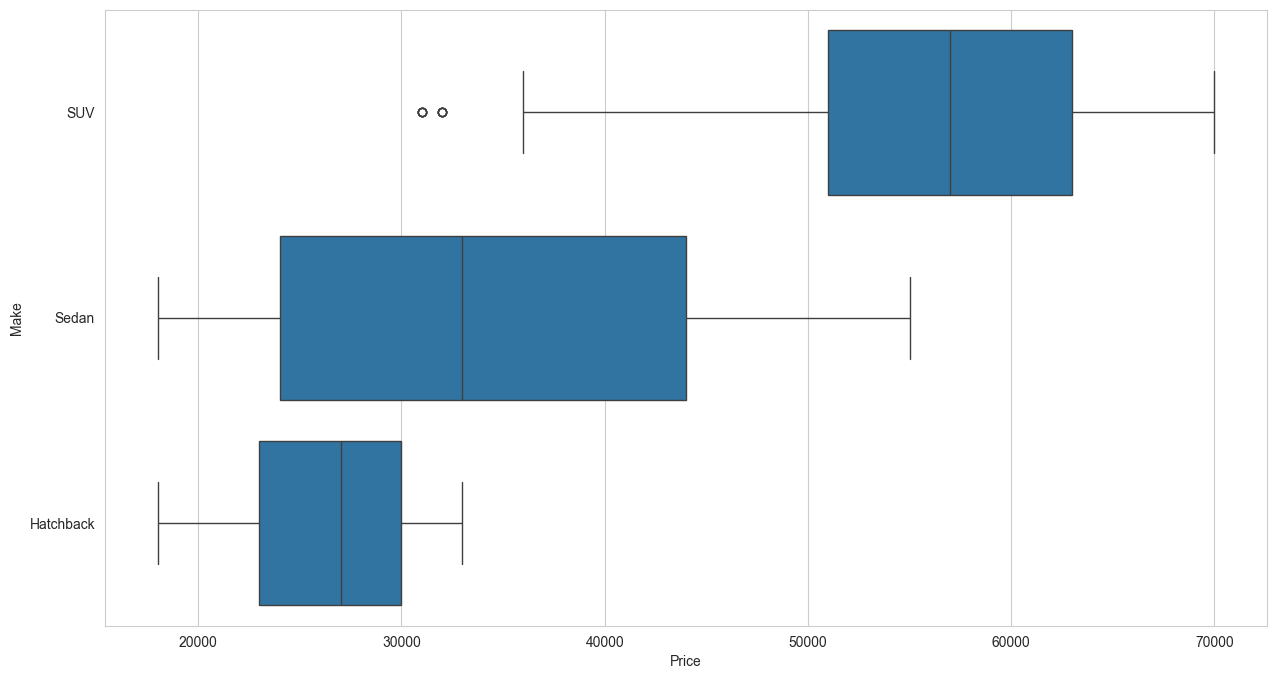

In [88]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df, x='Price', y='Make', orient='h')
plt.show()

* SUVs being most expensive, 75% pf its car priced more than 51K and chepest starting even after 32K and max going till 70k
* The diff of price is very clear as hatchback's lowest price is 10-11k and max going till 33-34K, which is median for Sedan but lowest for SUVs
* Sedan is having maximum varity in its price range starting as low as 10-11k , majority of 1st to 3rd quartile being in range of 25k to 45k.

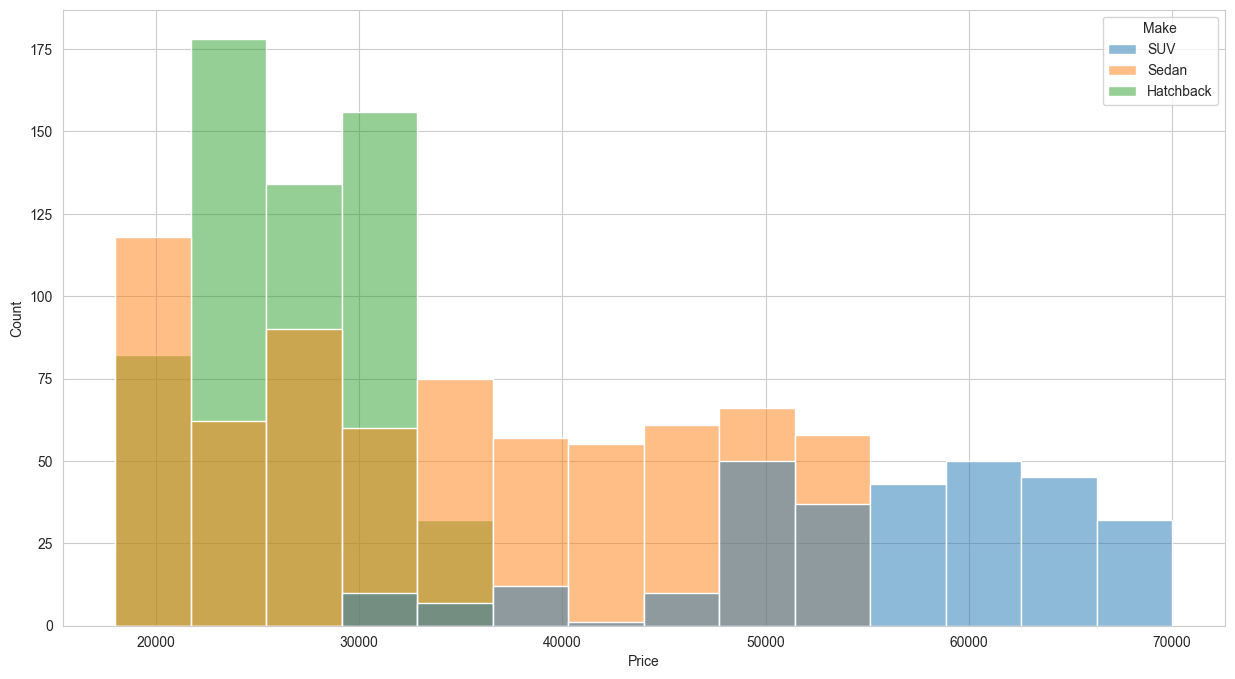

In [229]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x='Price', hue='Make')
plt.show()

* As expected most of the cars being sold are in the range of 20k to 35K
* Need to investigate relationship of total income and make

Relationship with Make and Total Income

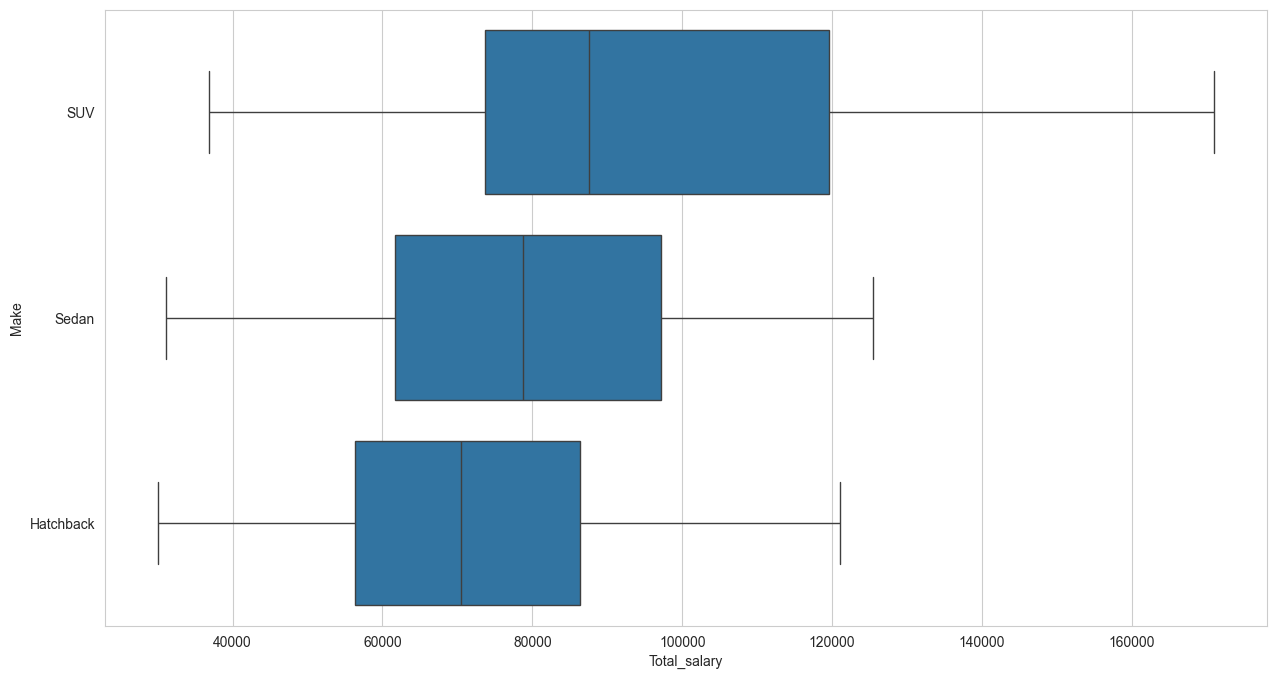

In [235]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df, x='Total_salary', y='Make')
plt.show()

* As we can see customers sentiment here, SUV being the most expensive are despite being the most expensive still are bought by people having salary range similar for Hatchback or Sedan car
* Need to investigate if its True or Not
* One of the learning also we had earlier that SUV owners are with least no of house loan, will also use this insight for investigation

In [130]:
low_salary_suv = df[(df['Make']=='SUV') & (df['Total_salary'] < 70000)]
low_salary_suv.shape[0]

51

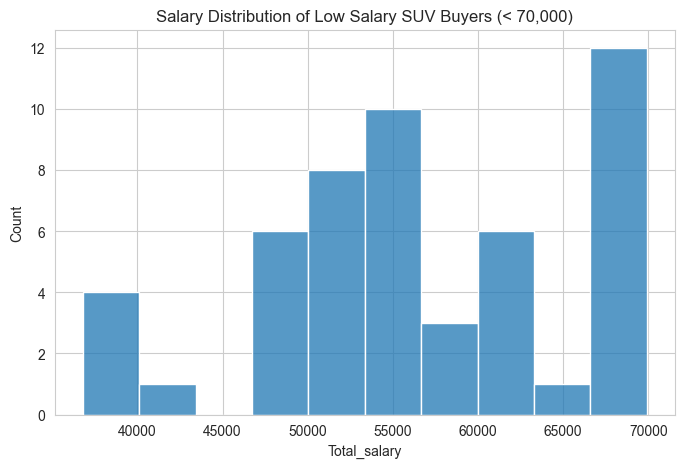

In [243]:
plt.figure(figsize=(8,5))
sns.histplot(data=low_salary_suv, x='Total_salary', bins=10)
plt.title('Salary Distribution of Low Salary SUV Buyers (< 70,000)')
plt.show()

In [240]:
low_salary_suv[['Total_salary','House_loan']].head()

,Total_salary,House_loan
165,55100,No
166,55500,No
202,69600,No
203,68600,No
204,65400,No


In [244]:
low_salary_suv[low_salary_suv['House_loan'] == ''][['Total_salary', 'House_loan']].count()

Total_salary    6
House_loan      6
dtype: int64

In [245]:
df['Salary_bin'] = pd.qcut(df['Total_salary'], q=4, labels=['Low','Mid','High','Very High'])

pd.crosstab(df['Salary_bin'], df['Make'], normalize='columns') * 100

Make,Hatchback,SUV,Sedan
Salary_bin,,,
Low,34.707904,11.447811,23.076923
Mid,26.116838,20.538721,25.925926
High,25.429553,25.925926,24.358974
Very High,13.745704,42.087542,26.638177


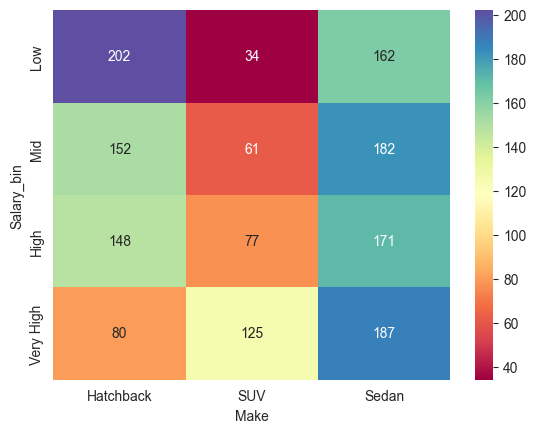

In [148]:
sns.heatmap(pd.crosstab(df['Salary_bin'], df['Make']), annot=True, fmt="d", cmap='Spectral')
plt.show()

* Contradictory to the previous assumptions,  SUV buyers are mostly very high-income households, clearly preferred by financially strong households, not middle or low income.
* Hatchback is the budget-first choice,Mostly bought by households with limited salary.
* Sedan is the middle-ground choice, not extremely budget, even among high-income groups, Sedans are extremely popular.

Gender vs Total_salary

In [282]:
gender_stats= pd.DataFrame({'Count': df['Gender'].value_counts(), 'Percentage':df['Gender'].value_counts(normalize=True)*100})
print(gender_stats)

         Count  Percentage
Gender                    
Male      1199   75.838077
Female     329   20.809614
Unknown     53    3.352309


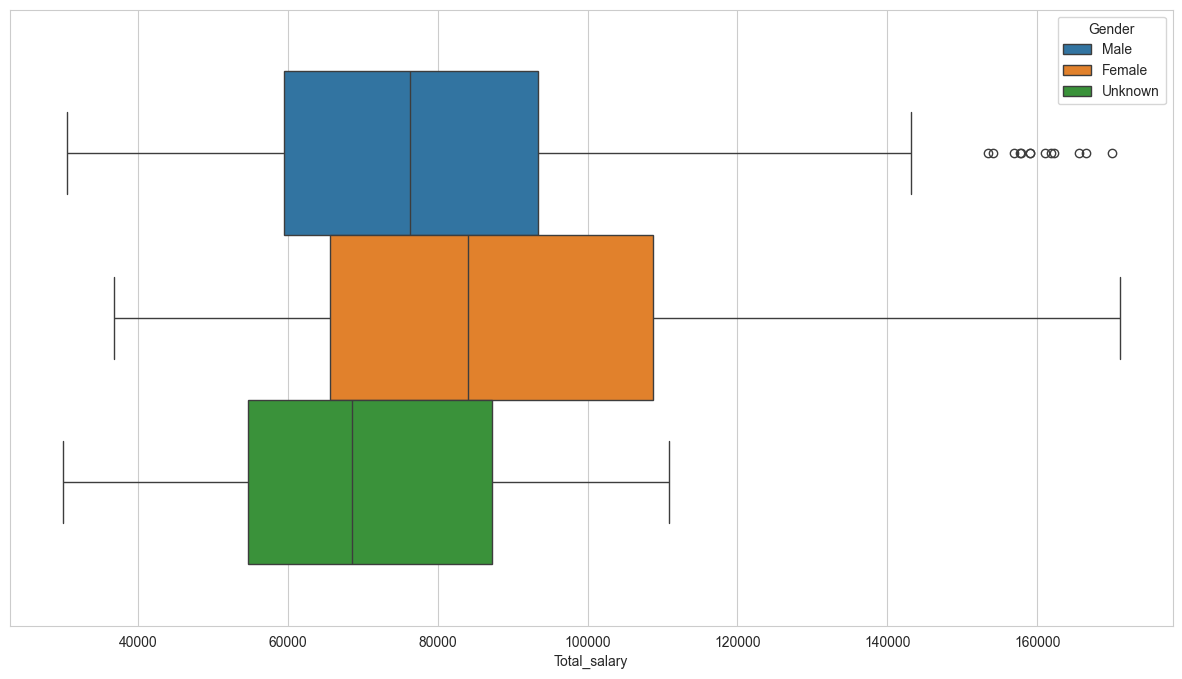

In [284]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df, x='Total_salary', hue='Gender')
plt.show()

* Female Gender have higher median salary, higher max salary and even higher min salary than male
* Although males have few outliers in terms of higher salary still behind females

In [156]:
df['Salary_bin'] = pd.qcut(df['Total_salary'], q=4, labels=['Low','Mid','High','Very High'])
pd.crosstab(df['Salary_bin'], df['Make'], values=df['Gender'], aggfunc=lambda x: (x=='Male').mean()*100)



Make,Hatchback,SUV,Sedan
Salary_bin,,,
Low,97.524752,32.352941,69.135802
Mid,96.052632,37.704918,75.824176
High,97.297297,46.753247,76.608187
Very High,97.500000,38.400000,72.192513


* Percentage of Car types bought by male

In [157]:
pd.crosstab(df['Salary_bin'], df['Make'], values=df['Gender'], aggfunc=lambda x: (x=='Female').mean()*100)


Make,Hatchback,SUV,Sedan
Salary_bin,,,
Low,1.980198,67.647059,18.518519
Mid,3.289474,59.016393,18.681319
High,2.702703,49.350649,19.298246
Very High,2.500000,60.800000,23.529412


* Percentage of Car types bought by Females

* Male people buy almost all Hatchback, female very less.
* SUV many female buy, especially low and very high salary people.
* Sedan mix but mostly male, not too much female but still more than Hatchback.

In [295]:
# Q3
salaried_males = df[(df['Profession']=='Salaried') & (df['Gender']=='Male')]


In [296]:
salaried_males['Make'].value_counts()

Make
Sedan        279
Hatchback    276
SUV           85
Name: count, dtype: int64

In [297]:
salaried_males['Make'].value_counts(normalize=True) * 100


Make
Sedan        43.59375
Hatchback    43.12500
SUV          13.28125
Name: proportion, dtype: float64

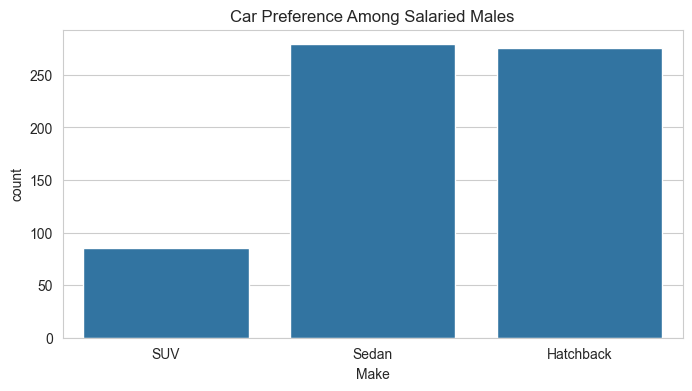

In [298]:
plt.figure(figsize=(8,4))
sns.countplot(data=salaried_males, x='Make')
plt.title('Car Preference Among Salaried Males')
plt.show()


In [321]:
# Q5
df.groupby('Personal_loan')['Price'].sum()

Personal_loan
No     28990000
Yes    27290000
Name: Price, dtype: int64